# Missing-data analysis — v3qc_v3 panel

How per-record missingness (`F_MISSING_post`) in the v3qc_v3 231-founder panel distributes,
and how it impacts the per-record AF comparison of `cactus_em` against (a) hapFIRE and (b) the FIXED recipe.

Scope: SEEDMIX_S1, Chr1.

Conventions:
- `F_MISSING_post` = fraction of the 231 founder calls that are `./.` in `founders_231_v3qc_v3.haploid.vcf.gz` (i.e. AFTER het-mask + AC=0 cleanup + mixed-ploidy merge).
- `recipe_af` = `AC_post / AN_post` from the same VCF — the FIXED recipe convention from `PIPELINE_STATE_2026-05-19.md` §4 (uniform h=1/231 applied through cn_var with the called mask). It's what the panel would predict for SEEDMIX if every called founder contributed equally and there were no drift or sequencing noise.
- `cactus_em alt_freq` = v3qc_v3 mixed-loose output, SEEDMIX_S1.
- `hapfire_af` = xwu's `s1_snp_frequency.txt`, SNP only.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from pathlib import Path
from scipy.stats import pearsonr

ROOT = Path('/global/scratch/users/tbellg/hapfire_sv')
CEM_TSV   = ROOT / 'scratch/v3qc_v3_mixedloose_chr1/SEEDMIX_S1.tsv'
HAPFIRE   = Path('/global/scratch/projects/fc_moilab/projects/grenenet-phase1/frequency/hapFIRE_frequencies/seed_mix/s1_snp_frequency.txt')
PANEL_ALL = ROOT / 'scratch/hetmask_diag/panel231_chr1_ALL_fmissing.tsv'      # all Chr1 records
PANEL_SNP = ROOT / 'scratch/hetmask_diag/panel231_chr1_snp_fmissing.tsv'      # Chr1 SNPs only
PG_PRE    = ROOT / 'scratch/hetmask_diag/pg_premask_chr1_snps.tsv'            # pre-mask PG SNPs
JOINED    = ROOT / 'scratch/hetmask_diag/joined_hetmask_chr1.tsv'             # pre-built 3-way join

FBINS   = [-1e-9, 0.0, 0.01, 0.05, 0.1, 0.2, 0.5, 1.01]
FLABELS = ['=0','(0,0.01]','(0.01,0.05]','(0.05,0.1]','(0.1,0.2]','(0.2,0.5]','>=0.5']

plt.rcParams['figure.dpi'] = 110

## 1. Distribution of missing records in the panel

Per-record `F_MISSING_post` on Chr1, across ALL variant types in `founders_231_v3qc_v3.haploid.vcf.gz` (n=1,589,277).


In [2]:
panel = pd.read_csv(
    PANEL_ALL, sep='\t', header=None,
    names=['chrom','pos','ref_len','alt_len','AC_post','AN_post','F_MISSING_post']
)
for c in ('AC_post','AN_post','F_MISSING_post'):
    panel[c] = pd.to_numeric(panel[c], errors='coerce')

def vclass(row):
    r, a = row['ref_len'], row['alt_len']
    if r == 1 and a == 1:
        return 'SNP'
    sz = abs(r - a)
    if sz < 50 and (r == 1 or a == 1):
        return 'small_indel'
    if sz >= 50:
        return 'SV (>=50bp)'
    return 'complex'

panel['vclass'] = panel.apply(vclass, axis=1)
panel['fmiss_bin'] = pd.cut(panel['F_MISSING_post'], bins=FBINS, labels=FLABELS)

print(f'Chr1 records in v3qc_v3 panel: {len(panel):,}')
print('\nVariant-class breakdown:')
print(panel.groupby('vclass', observed=True).size().to_string())
print('\nOverall F_MISSING_post summary:')
print(panel['F_MISSING_post'].describe(percentiles=[0.5,0.9,0.95,0.99]).round(4).to_string())

Chr1 records in v3qc_v3 panel: 1,589,277

Variant-class breakdown:
vclass
SNP            1029469
SV (>=50bp)      65440
complex         204339
small_indel     290029

Overall F_MISSING_post summary:
count    1.589277e+06
mean     5.590000e-02
std      8.600000e-02
min      0.000000e+00
50%      1.300000e-02
90%      1.732000e-01
95%      2.208000e-01
99%      3.506000e-01
max      9.827000e-01


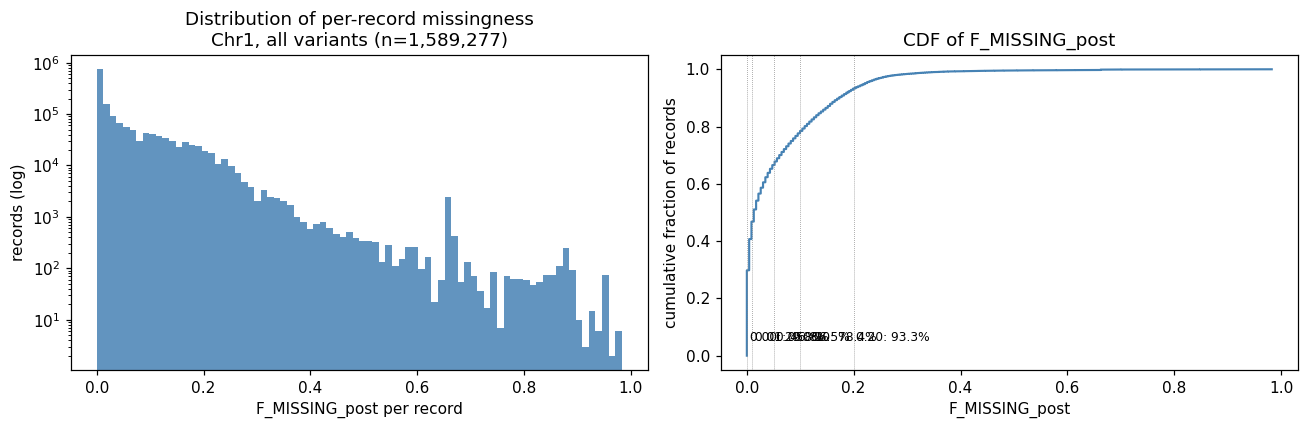

In [3]:
# Histogram + cumulative distribution of F_MISSING_post
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(panel['F_MISSING_post'], bins=80, color='steelblue', alpha=0.85)
axes[0].set_yscale('log')
axes[0].set_xlabel('F_MISSING_post per record')
axes[0].set_ylabel('records (log)')
axes[0].set_title(f'Distribution of per-record missingness\nChr1, all variants (n={len(panel):,})')

vals = np.sort(panel['F_MISSING_post'].values)
cdf = np.arange(1, len(vals)+1) / len(vals)
axes[1].plot(vals, cdf, color='steelblue', lw=1.4)
axes[1].set_xlabel('F_MISSING_post')
axes[1].set_ylabel('cumulative fraction of records')
axes[1].set_title('CDF of F_MISSING_post')
for x in (0.0, 0.01, 0.05, 0.1, 0.2):
    f = (vals <= x).mean()
    axes[1].axvline(x, color='grey', ls=':', lw=0.5)
    axes[1].text(x+0.005, 0.05, f'{x:.2f}: {f:.1%}', fontsize=8)

plt.tight_layout()
plt.savefig(ROOT / 'plots/MISSING_DISTRIBUTION_v3qc_v3_chr1.png', dpi=140, bbox_inches='tight')
plt.show()

Records per (F_MISSING_post bin, variant class):
vclass          SNP  SV (>=50bp)  complex  small_indel
fmiss_bin                                             
=0           387623         2496    13400        69924
(0,0.01]     213204         2156    11712        43155
(0.01,0.05]  219715         5277    25624        63116
(0.05,0.1]   105085         7723    30772        45758
(0.1,0.2]     70203        28756    86038        50958
(0.2,0.5]     31678        16718    34813        16687
>=0.5          1961         2314     1980          431

Percentage within variant class:
vclass         SNP  SV (>=50bp)  complex  small_indel
fmiss_bin                                            
=0           37.65         3.81     6.56        24.11
(0,0.01]     20.71         3.29     5.73        14.88
(0.01,0.05]  21.34         8.06    12.54        21.76
(0.05,0.1]   10.21        11.80    15.06        15.78
(0.1,0.2]     6.82        43.94    42.11        17.57
(0.2,0.5]     3.08        25.55    17.04    

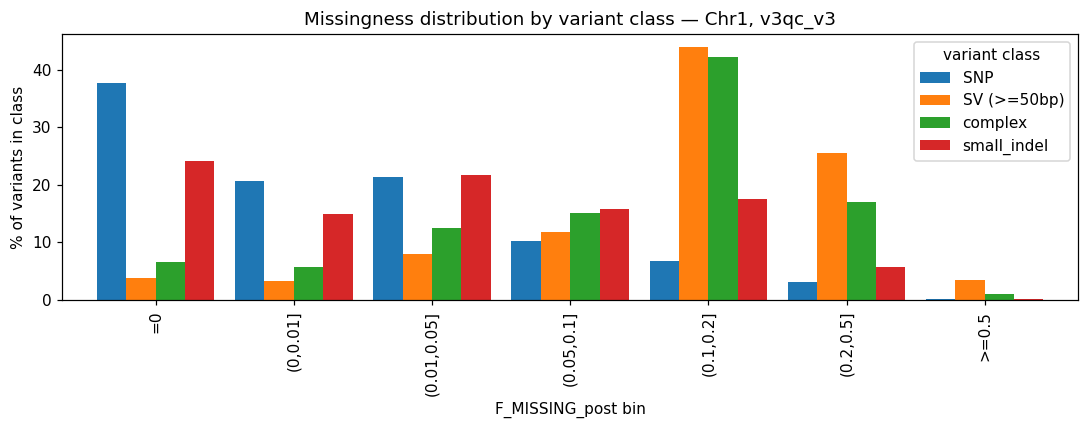

In [4]:
# Variant-class-stratified bar chart
ct = pd.crosstab(panel['fmiss_bin'], panel['vclass'])
ct_pct = ct.div(ct.sum(axis=0), axis=1) * 100
print('Records per (F_MISSING_post bin, variant class):')
print(ct.to_string())
print('\nPercentage within variant class:')
print(ct_pct.round(2).to_string())

fig, ax = plt.subplots(figsize=(10,4))
ct_pct.plot(kind='bar', ax=ax, width=0.85)
ax.set_ylabel('% of variants in class')
ax.set_xlabel('F_MISSING_post bin')
ax.set_title('Missingness distribution by variant class — Chr1, v3qc_v3')
ax.legend(title='variant class', loc='upper right')
plt.tight_layout()
plt.savefig(ROOT / 'plots/MISSING_BY_VCLASS_v3qc_v3_chr1.png', dpi=140, bbox_inches='tight')
plt.show()

**Observation.** Among biallelic SNPs roughly 30% of records sit at `F_MISSING_post = 0`; the rest are spread across (0, 0.5]. SV records are concentrated at slightly higher F_MISSING_post because cactus haploid `.` (assembly didn't traverse the bubble) contributes there.

## 2. Impact on cactus_em vs hapFIRE

Restricted to biallelic Chr1 SNPs joinable with hapFIRE (n=517,206). The diagnostic in `scratch/hetmask_diag/` showed that pre-mask PG het rate is statistically correlated with the residual but explains only R²≈0.005 of total variance; the dominant axis is `F_MISSING_post`.


In [5]:
J = pd.read_csv(JOINED, sep='\t')
# Attach F_MISSING_post from the all-records panel table
fm_snp = panel[(panel['ref_len']==1) & (panel['alt_len']==1)][
    ['chrom','pos','F_MISSING_post','AC_post','AN_post']
]
# 'chrom' in J is 'Chr1'; panel chrom is also 'Chr1'
before = len(J)
J = J.merge(fm_snp, on=['chrom','pos'], how='inner')
J['residual_hf'] = J['hapfire_af'] - J['alt_freq']
J['fmiss_bin']   = pd.cut(J['F_MISSING_post'], bins=FBINS, labels=FLABELS)
print(f'joined rows (after attaching F_MISSING_post): {len(J):,}  (was {before:,})')

def agg_metrics(df, est_col, truth_col, label):
    res = df[truth_col] - df[est_col]
    out = pd.Series({
        'n': len(df),
        'MAE': np.abs(res).mean(),
        'RMSE': np.sqrt((res**2).mean()),
        'mean_bias': res.mean(),
        'R2': pearsonr(df[est_col], df[truth_col]).statistic**2,
        '%|d|>0.05': (np.abs(res) > 0.05).mean()*100,
        '%|d|>0.10': (np.abs(res) > 0.10).mean()*100,
    })
    out.name = label
    return out

# Headline: agreement at panel-complete vs panel-incomplete subsets
scenarios = {
    'all joined'           : J,
    'F_MISSING_post = 0'   : J[J['F_MISSING_post']==0],
    'F_MISSING_post < 0.01': J[J['F_MISSING_post']<0.01],
    'F_MISSING_post < 0.05': J[J['F_MISSING_post']<0.05],
    'F_MISSING_post >= 0.10': J[J['F_MISSING_post']>=0.10],
}
rows = [agg_metrics(d, 'alt_freq', 'hapfire_af', k) for k,d in scenarios.items()]
tab = pd.DataFrame(rows).round(5)
print('\ncactus_em vs hapFIRE:')
print(tab.to_string())

joined rows (after attaching F_MISSING_post): 517,206  (was 517,206)

cactus_em vs hapFIRE:
                               n      MAE     RMSE  mean_bias       R2  %|d|>0.05  %|d|>0.10
all joined              517206.0  0.01499  0.03839    0.00150  0.96778    3.86500    0.88823
F_MISSING_post = 0      172699.0  0.00684  0.01243   -0.00190  0.99098    0.24493    0.03995
F_MISSING_post < 0.01   312325.0  0.00869  0.01656   -0.00130  0.98997    0.67334    0.09093
F_MISSING_post < 0.05   442866.0  0.01153  0.02332   -0.00018  0.98611    1.87709    0.29422
F_MISSING_post >= 0.10   26054.0  0.05004  0.11730    0.01950  0.79095   22.96768    7.81070


cactus_em vs hapFIRE, stratified by F_MISSING_post:
                  n      MAE  mean_bias     out05     out10
fmiss_bin                                                  
=0           172699  0.00684   -0.00190   0.24493   0.03995
(0,0.01]     139626  0.01098   -0.00056   1.20321   0.15398
(0.01,0.05]  130541  0.01832    0.00251   4.75713   0.78060
(0.05,0.1]    48286  0.02785    0.00716  11.79017   2.60117
(0.1,0.2]     24210  0.04562    0.01753  21.53242   6.44362
(0.2,0.5]      1834  0.10687    0.04631  41.60305  25.46347
>=0.5            10  0.33092   -0.12339  80.00000  80.00000


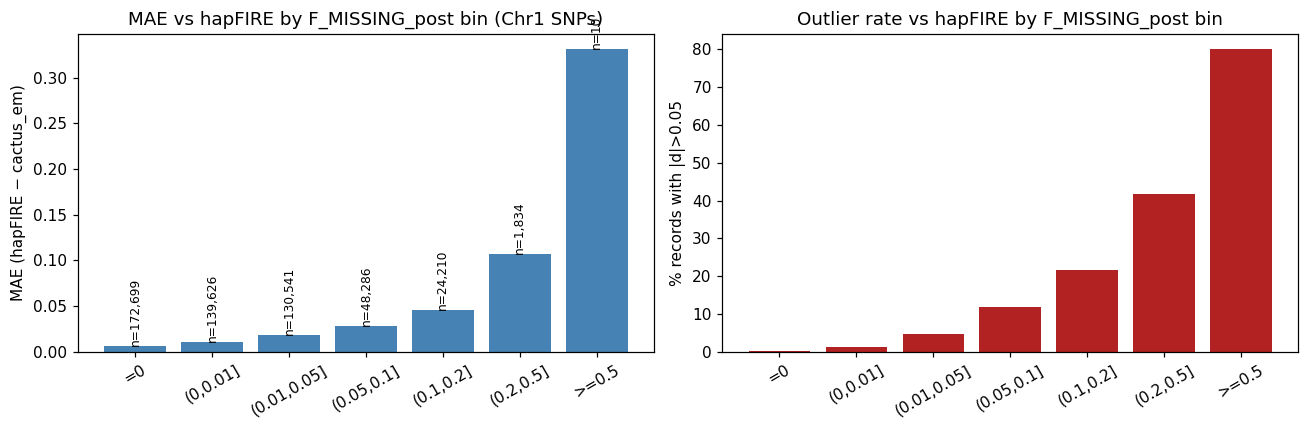

In [6]:
# Stratified MAE / outlier-rate by F_MISSING_post bin
binsum_hf = J.groupby('fmiss_bin', observed=True).agg(
    n         = ('residual_hf','size'),
    MAE       = ('residual_hf', lambda v: np.abs(v).mean()),
    mean_bias = ('residual_hf','mean'),
    out05     = ('residual_hf', lambda v: (np.abs(v)>0.05).mean()*100),
    out10     = ('residual_hf', lambda v: (np.abs(v)>0.10).mean()*100),
).round(5)
print('cactus_em vs hapFIRE, stratified by F_MISSING_post:')
print(binsum_hf.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(binsum_hf))
axes[0].bar(x, binsum_hf['MAE'], color='steelblue')
axes[0].set_xticks(x); axes[0].set_xticklabels(binsum_hf.index, rotation=30)
axes[0].set_ylabel('MAE (hapFIRE − cactus_em)')
axes[0].set_title('MAE vs hapFIRE by F_MISSING_post bin (Chr1 SNPs)')
for i,(v,n) in enumerate(zip(binsum_hf['MAE'], binsum_hf['n'])):
    axes[0].text(i, v, f'n={n:,}', rotation=90, va='bottom', ha='center', fontsize=8)
axes[1].bar(x, binsum_hf['out05'], color='firebrick')
axes[1].set_xticks(x); axes[1].set_xticklabels(binsum_hf.index, rotation=30)
axes[1].set_ylabel('% records with |d|>0.05')
axes[1].set_title('Outlier rate vs hapFIRE by F_MISSING_post bin')
plt.tight_layout()
plt.savefig(ROOT / 'plots/MISSING_VS_HAPFIRE_v3qc_v3_chr1.png', dpi=140, bbox_inches='tight')
plt.show()

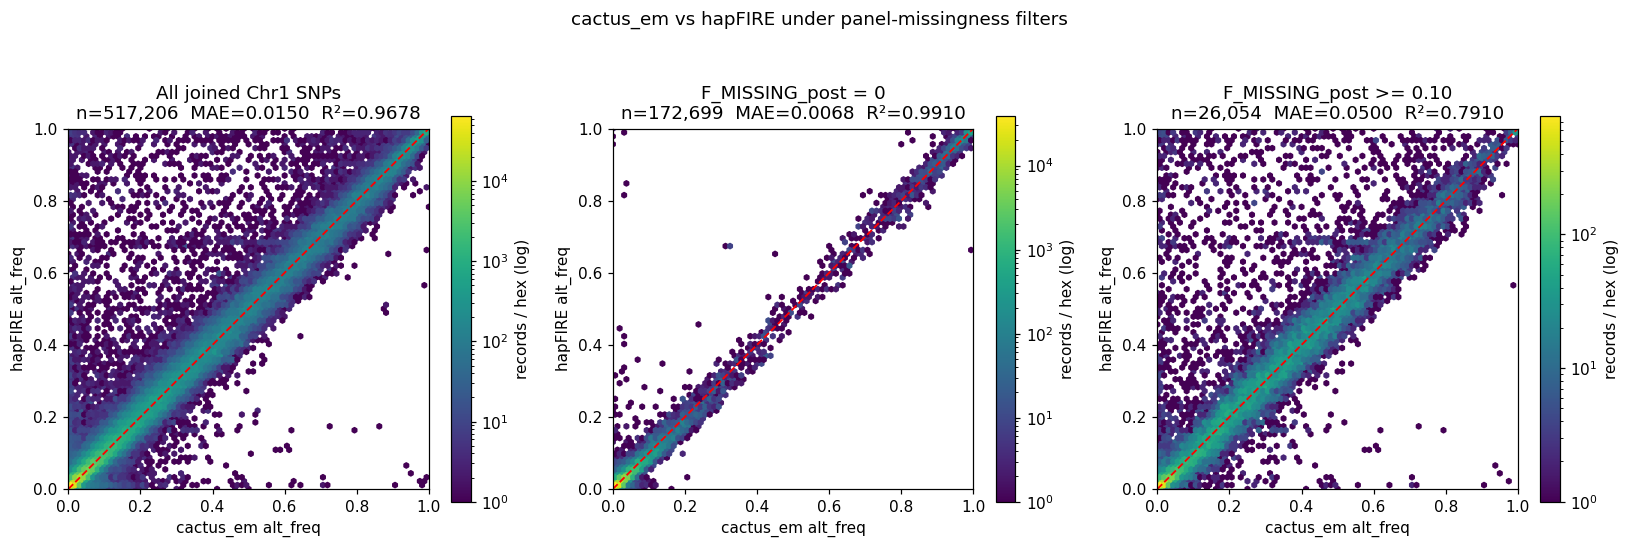

In [7]:
# Hexbin scatters: all / F_MISSING=0 / F_MISSING>=0.10
sub_no = J[J['F_MISSING_post']==0]
sub_hi = J[J['F_MISSING_post']>=0.10]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, df, ttl in [(axes[0], J,      'All joined Chr1 SNPs'),
                    (axes[1], sub_no, 'F_MISSING_post = 0'),
                    (axes[2], sub_hi, 'F_MISSING_post >= 0.10')]:
    hb = ax.hexbin(df['alt_freq'], df['hapfire_af'], gridsize=80,
                   extent=(0,1,0,1), norm=LogNorm(vmin=1), mincnt=1, cmap='viridis')
    ax.plot([0,1],[0,1], color='red', lw=1.2, ls='--')
    mae = np.abs(df['hapfire_af']-df['alt_freq']).mean()
    r2 = pearsonr(df['alt_freq'], df['hapfire_af']).statistic**2
    ax.set_title(f'{ttl}\nn={len(df):,}  MAE={mae:.4f}  R²={r2:.4f}')
    ax.set_xlabel('cactus_em alt_freq'); ax.set_ylabel('hapFIRE alt_freq')
    ax.set_aspect('equal'); ax.set_xlim(0,1); ax.set_ylim(0,1)
    fig.colorbar(hb, ax=ax, shrink=0.8).set_label('records / hex (log)')
plt.suptitle('cactus_em vs hapFIRE under panel-missingness filters', y=1.01)
plt.tight_layout()
plt.savefig(ROOT / 'plots/SCATTER_HAPFIRE_BY_MISSING_v3qc_v3_chr1.png', dpi=140, bbox_inches='tight')
plt.show()

## 3. Impact on cactus_em vs FIXED recipe

The recipe truth (uniform h=1/231 projected through cn_var with the called mask) is `recipe_af = AC_post / AN_post`.
Computed on the same Chr1 biallelic SNPs joined above, plus separately on ALL Chr1 records (SNPs + indels + SVs) to expose how the F_MISSING gradient impacts non-SNP variants where hapFIRE has no opinion.


In [8]:
# (a) SNP-only join (overlaps the hapFIRE comparison)
J['recipe_af']    = np.where(J['AN_post']>0, J['AC_post']/J['AN_post'], np.nan)
J['residual_rec'] = J['recipe_af'] - J['alt_freq']

scenarios_rec = {
    'all joined'           : J,
    'F_MISSING_post = 0'   : J[J['F_MISSING_post']==0],
    'F_MISSING_post < 0.01': J[J['F_MISSING_post']<0.01],
    'F_MISSING_post < 0.05': J[J['F_MISSING_post']<0.05],
    'F_MISSING_post >= 0.10': J[J['F_MISSING_post']>=0.10],
}
rows = [agg_metrics(d, 'alt_freq', 'recipe_af', k) for k,d in scenarios_rec.items()]
tab_rec = pd.DataFrame(rows).round(5)
print('cactus_em vs FIXED recipe (Chr1 SNPs joined with hapFIRE):')
print(tab_rec.to_string())

# Stratified per-bin
binsum_rec = J.groupby('fmiss_bin', observed=True).agg(
    n=('residual_rec','size'),
    MAE=('residual_rec', lambda v: np.abs(v).mean()),
    mean_bias=('residual_rec','mean'),
    out05=('residual_rec', lambda v: (np.abs(v)>0.05).mean()*100),
    out10=('residual_rec', lambda v: (np.abs(v)>0.10).mean()*100),
).round(5)
print('\ncactus_em vs recipe, stratified by F_MISSING_post (SNPs):')
print(binsum_rec.to_string())

cactus_em vs FIXED recipe (Chr1 SNPs joined with hapFIRE):
                               n      MAE     RMSE  mean_bias       R2  %|d|>0.05  %|d|>0.10
all joined              517206.0  0.01318  0.01971   -0.00134  0.99136    3.40967    0.10228
F_MISSING_post = 0      172699.0  0.00763  0.01108   -0.00115  0.99273    0.43312    0.00926
F_MISSING_post < 0.01   312325.0  0.00941  0.01404   -0.00135  0.99282    1.17602    0.02273
F_MISSING_post < 0.05   442866.0  0.01176  0.01757   -0.00143  0.99216    2.42602    0.04516
F_MISSING_post >= 0.10   26054.0  0.02316  0.03194   -0.00016  0.98157   11.17295    0.87511

cactus_em vs recipe, stratified by F_MISSING_post (SNPs):
                  n      MAE  mean_bias     out05     out10
fmiss_bin                                                  
=0           172699  0.00763   -0.00115   0.43312   0.00926
(0,0.01]     139626  0.01162   -0.00158   2.09488   0.03939
(0.01,0.05]  130541  0.01737   -0.00164   5.41669   0.09882
(0.05,0.1]    48286  0.0

MAE per F_MISSING_post bin: hapFIRE vs recipe
                  n   MAE_hf  out05_hf  MAE_rec  out05_rec
fmiss_bin                                                 
=0           172699  0.00684   0.24493  0.00763    0.43312
(0,0.01]     139626  0.01098   1.20321  0.01162    2.09488
(0.01,0.05]  130541  0.01832   4.75713  0.01737    5.41669
(0.05,0.1]    48286  0.02785  11.79017  0.02085    8.24255
(0.1,0.2]     24210  0.04562  21.53242  0.02252   10.39240
(0.2,0.5]      1834  0.10687  41.60305  0.03153   21.48310
>=0.5            10  0.33092  80.00000  0.02459   10.00000


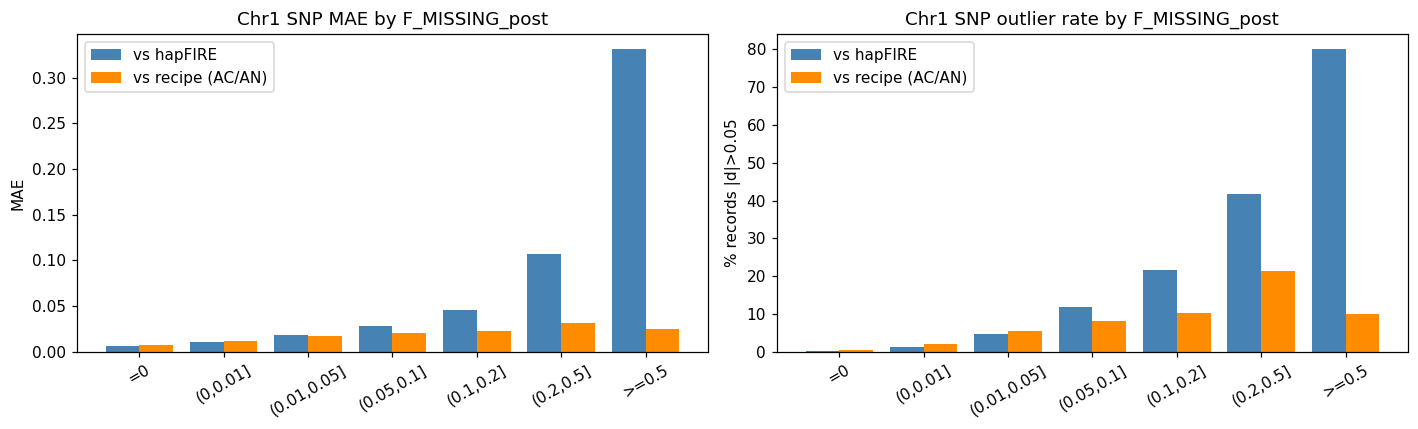

In [9]:
# Side-by-side: MAE per F_MISSING_post bin, hapFIRE vs recipe
merged = binsum_hf[['n','MAE','out05']].rename(columns={'MAE':'MAE_hf','out05':'out05_hf'})\
         .join(binsum_rec[['MAE','out05']].rename(columns={'MAE':'MAE_rec','out05':'out05_rec'}))
print('MAE per F_MISSING_post bin: hapFIRE vs recipe')
print(merged.round(5).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
x = np.arange(len(merged))
w = 0.4
axes[0].bar(x-w/2, merged['MAE_hf'],  width=w, color='steelblue', label='vs hapFIRE')
axes[0].bar(x+w/2, merged['MAE_rec'], width=w, color='darkorange', label='vs recipe (AC/AN)')
axes[0].set_xticks(x); axes[0].set_xticklabels(merged.index, rotation=30)
axes[0].set_ylabel('MAE'); axes[0].legend(); axes[0].set_title('Chr1 SNP MAE by F_MISSING_post')
axes[1].bar(x-w/2, merged['out05_hf'],  width=w, color='steelblue', label='vs hapFIRE')
axes[1].bar(x+w/2, merged['out05_rec'], width=w, color='darkorange', label='vs recipe (AC/AN)')
axes[1].set_xticks(x); axes[1].set_xticklabels(merged.index, rotation=30)
axes[1].set_ylabel('% records |d|>0.05'); axes[1].legend()
axes[1].set_title('Chr1 SNP outlier rate by F_MISSING_post')
plt.tight_layout()
plt.savefig(ROOT / 'plots/MISSING_HAPFIRE_VS_RECIPE_v3qc_v3_chr1.png', dpi=140, bbox_inches='tight')
plt.show()

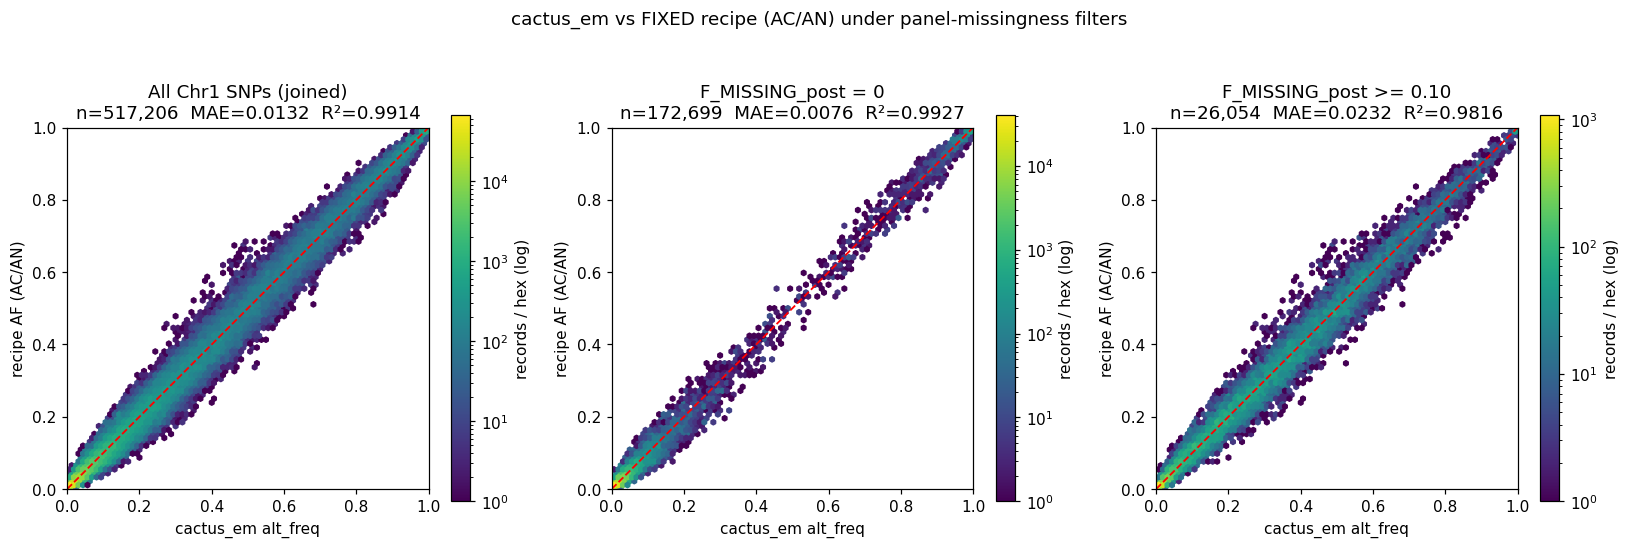

In [10]:
# Hexbin: cactus_em vs recipe under panel-missingness filters (SNPs only, for direct comparability)
sub_no = J[J['F_MISSING_post']==0]
sub_hi = J[J['F_MISSING_post']>=0.10]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, df, ttl in [(axes[0], J,      'All Chr1 SNPs (joined)'),
                    (axes[1], sub_no, 'F_MISSING_post = 0'),
                    (axes[2], sub_hi, 'F_MISSING_post >= 0.10')]:
    hb = ax.hexbin(df['alt_freq'], df['recipe_af'], gridsize=80,
                   extent=(0,1,0,1), norm=LogNorm(vmin=1), mincnt=1, cmap='viridis')
    ax.plot([0,1],[0,1], color='red', lw=1.2, ls='--')
    mae = np.abs(df['recipe_af']-df['alt_freq']).mean()
    r2  = pearsonr(df['alt_freq'], df['recipe_af']).statistic**2
    ax.set_title(f'{ttl}\nn={len(df):,}  MAE={mae:.4f}  R²={r2:.4f}')
    ax.set_xlabel('cactus_em alt_freq'); ax.set_ylabel('recipe AF (AC/AN)')
    ax.set_aspect('equal'); ax.set_xlim(0,1); ax.set_ylim(0,1)
    fig.colorbar(hb, ax=ax, shrink=0.8).set_label('records / hex (log)')
plt.suptitle('cactus_em vs FIXED recipe (AC/AN) under panel-missingness filters', y=1.01)
plt.tight_layout()
plt.savefig(ROOT / 'plots/SCATTER_RECIPE_BY_MISSING_v3qc_v3_chr1.png', dpi=140, bbox_inches='tight')
plt.show()

### Genome-wide recipe view (all variant types, Chr1)

Recipe AF can be computed for every record in `cn_var` (not just SNPs that hapFIRE happens to cover). Below: how the F_MISSING_post gradient impacts the cactus_em–vs–recipe agreement on SNPs vs small indels vs SVs.


In [11]:
# Genome-wide cactus_em + recipe (using the all-records panel table)
cem = pd.read_csv(CEM_TSV, sep='\t')
cem = cem[cem['chrom']=='Chr1'].copy()
panel_chr1 = panel[['chrom','pos','ref_len','alt_len','AC_post','AN_post','F_MISSING_post','vclass','fmiss_bin']]
# Join by row order: the cactus_em TSV is in cn_var-column order. For multi-allelic positions
# we need (chrom,pos,ref_len,alt_len) — but cem doesn't carry ref/alt bases.
# Restrict to biallelic-per-(chrom,pos,ref_len,alt_len) only (1:1).
key_cols = ['chrom','pos','ref_len','alt_len']
panel_chr1 = panel_chr1.groupby(key_cols, observed=True).first().reset_index()  # keep one row per key
G = cem.merge(panel_chr1, on=key_cols, how='inner')
# Drop ambiguous multi-allelic-at-same-len rows on the cem side
G = G.drop_duplicates(subset=key_cols, keep=False)
G['recipe_af']    = np.where(G['AN_post']>0, G['AC_post']/G['AN_post'], np.nan)
G['residual_rec'] = G['recipe_af'] - G['alt_freq']
print(f'cactus_em ↔ recipe joined Chr1 (biallelic by key): {len(G):,}')

# Per-variant-class agreement, stratified by F_MISSING_post bin
def per_bin(df, label):
    b = df.groupby('fmiss_bin', observed=True).agg(
        n=('residual_rec','size'),
        MAE=('residual_rec', lambda v: np.abs(v).mean()),
        mean_bias=('residual_rec','mean'),
        out05=('residual_rec', lambda v: (np.abs(v)>0.05).mean()*100),
    ).round(5)
    b['vclass'] = label
    return b

parts = []
for v in ('SNP','small_indel','SV (>=50bp)'):
    parts.append(per_bin(G[G['vclass']==v], v))
by_vc = pd.concat(parts).reset_index()
print('\ncactus_em vs recipe, by F_MISSING_post bin × variant class (Chr1):')
print(by_vc.to_string())

cactus_em ↔ recipe joined Chr1 (biallelic by key): 1,436,987



cactus_em vs recipe, by F_MISSING_post bin × variant class (Chr1):
      fmiss_bin       n      MAE  mean_bias     out05       vclass
0            =0  378499  0.00577   -0.00024   0.23884          SNP
1      (0,0.01]  203947  0.01018   -0.00123   1.65043          SNP
2   (0.01,0.05]  204610  0.01589   -0.00169   4.73193          SNP
3    (0.05,0.1]   95000  0.01911   -0.00138   7.59368          SNP
4     (0.1,0.2]   63789  0.01929   -0.00188   8.65510          SNP
5     (0.2,0.5]   29888  0.03141   -0.00851  21.51700          SNP
6         >=0.5    1750  0.05114   -0.00076  39.08571          SNP
7            =0   69151  0.00527    0.00027   0.18510  small_indel
8      (0,0.01]   41870  0.00896   -0.00065   1.20134  small_indel
9   (0.01,0.05]   58923  0.01353   -0.00118   3.50797  small_indel
10   (0.05,0.1]   40992  0.01481   -0.00104   4.68628  small_indel
11    (0.1,0.2]   44739  0.01423   -0.00143   4.49272  small_indel
12    (0.2,0.5]   14764  0.01516   -0.00282   6.02140  small_

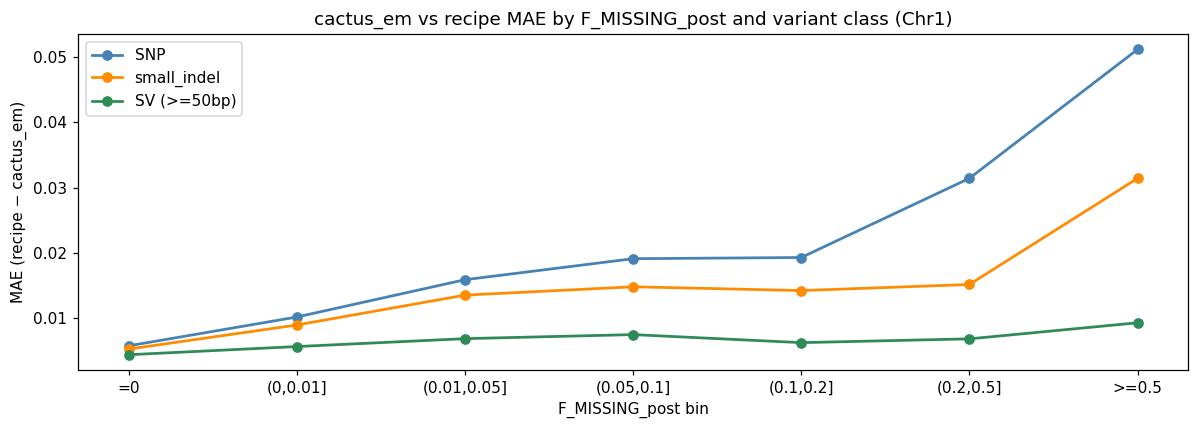

In [12]:
fig, ax = plt.subplots(figsize=(11, 4))
for v, color in [('SNP','steelblue'),('small_indel','darkorange'),('SV (>=50bp)','seagreen')]:
    d = by_vc[by_vc['vclass']==v]
    ax.plot(d['fmiss_bin'].astype(str), d['MAE'], marker='o', color=color, label=v, lw=1.8)
ax.set_ylabel('MAE (recipe − cactus_em)')
ax.set_xlabel('F_MISSING_post bin')
ax.set_title('cactus_em vs recipe MAE by F_MISSING_post and variant class (Chr1)')
ax.legend()
plt.tight_layout()
plt.savefig(ROOT / 'plots/RECIPE_MAE_BY_FMISS_VCLASS_v3qc_v3_chr1.png', dpi=140, bbox_inches='tight')
plt.show()

## 4. Where does the missingness come from?

At Chr1 biallelic SNPs with `F_MISSING_post >= 0.10`, every missing cell traces to one of three buckets:

| Source | Definition | Fix |
|---|---|---|
| `n_hetmask_pg` | PG cell was `0/1` pre-mask, `./.` post-mask | (A) relax het-mask |
| `n_premissing_pg` | PG cell was already `./.` pre-mask (GQ<20, PanGenie no-call, or cactus-only record) | (B) Beagle SNP imputation |
| `n_cactus_missing` | Cactus haploid `.` (assembly didn't traverse bubble) | structural; not panel-fixable |

These are mutually exclusive — a cell maps to exactly one bucket. We can compute all three from data already on hand:

- `n_hetmask_pg(r)  = AC_Het_pre(r)`
- `n_premissing_pg(r) = (306 - AN_pre)/2`
- `n_cactus_missing(r) = (231 - AN_post) - n_hetmask_pg - n_premissing_pg`

Then ask: does the residual scale with which bucket?


In [13]:
# Decompose missing cells per record
J['n_hetmask_pg']     = J['AC_Het'].astype(int)
J['n_premissing_pg']  = ((306 - J['AN_pre']) / 2).astype(int)
J['n_missing_total']  = (231 - J['AN_post']).astype(int)
J['n_cactus_missing'] = J['n_missing_total'] - J['n_hetmask_pg'] - J['n_premissing_pg']

neg = (J['n_cactus_missing'] < 0).sum()
print(f'sanity: rows with n_cactus_missing < 0  = {neg:,}  ({100*neg/len(J):.4f}%)')

HI = J[J['F_MISSING_post'] >= 0.10].copy()
HI['share_hetmask']    = HI['n_hetmask_pg']    / HI['n_missing_total'].clip(lower=1)
HI['share_premissing'] = HI['n_premissing_pg'] / HI['n_missing_total'].clip(lower=1)
HI['share_cactus']     = HI['n_cactus_missing']/ HI['n_missing_total'].clip(lower=1)

print(f'\nrecords with F_MISSING_post >= 0.10 : {len(HI):,}\n')
print('Mean per-record CELL COUNT per bucket:')
print(f'  n_hetmask_pg      = {HI["n_hetmask_pg"].mean():.2f}')
print(f'  n_premissing_pg   = {HI["n_premissing_pg"].mean():.2f}')
print(f'  n_cactus_missing  = {HI["n_cactus_missing"].mean():.2f}')
print(f'  n_missing_total   = {HI["n_missing_total"].mean():.2f}')

print('\nMean per-record SHARE per bucket (fraction of missing):')
print(f'  share_hetmask    = {HI["share_hetmask"].mean():.3f}')
print(f'  share_premissing = {HI["share_premissing"].mean():.3f}')
print(f'  share_cactus     = {HI["share_cactus"].mean():.3f}')


sanity: rows with n_cactus_missing < 0  = 0  (0.0000%)

records with F_MISSING_post >= 0.10 : 26,054

Mean per-record CELL COUNT per bucket:
  n_hetmask_pg      = 3.76
  n_premissing_pg   = 26.18
  n_cactus_missing  = 2.60
  n_missing_total   = 32.54

Mean per-record SHARE per bucket (fraction of missing):
  share_hetmask    = 0.118
  share_premissing = 0.820
  share_cactus     = 0.062


In [14]:
# Multivariate OLS: residual ~ n_hetmask + n_premissing + n_cactus
X = HI[['n_hetmask_pg','n_premissing_pg','n_cactus_missing']].values.astype(float)
y = HI['residual_hf'].values.astype(float)
X1 = np.hstack([X, np.ones((len(X),1))])
b, *_ = np.linalg.lstsq(X1, y, rcond=None)
yhat = X1 @ b
r2 = 1 - ((y - yhat)**2).sum() / ((y - y.mean())**2).sum()
print('OLS: residual_hf = a*n_hetmask + b*n_premissing + c*n_cactus + d')
print(f'  coef n_hetmask_pg     = {b[0]:+.6f}  (per missing cell)')
print(f'  coef n_premissing_pg  = {b[1]:+.6f}')
print(f'  coef n_cactus_missing = {b[2]:+.6f}')
print(f'  intercept             = {b[3]:+.6f}')
print(f'  R^2                   = {r2:.4f}')

mh = HI['n_hetmask_pg'].mean()
mp = HI['n_premissing_pg'].mean()
mc = HI['n_cactus_missing'].mean()
print(f'\nContribution to mean residual at mean per-record counts:')
print(f'  het-mask    : {b[0]*mh:+.5f}   ({100*b[0]*mh/HI["residual_hf"].mean():+.1f}% of actual mean)')
print(f'  pre-missing : {b[1]*mp:+.5f}   ({100*b[1]*mp/HI["residual_hf"].mean():+.1f}%)')
print(f'  cactus      : {b[2]*mc:+.5f}   ({100*b[2]*mc/HI["residual_hf"].mean():+.1f}%)')
print(f'  intercept   : {b[3]:+.5f}')
print(f'  total pred  : {b[0]*mh+b[1]*mp+b[2]*mc+b[3]:+.5f}')
print(f'  actual mean : {HI["residual_hf"].mean():+.5f}')


OLS: residual_hf = a*n_hetmask + b*n_premissing + c*n_cactus + d
  coef n_hetmask_pg     = -0.002192  (per missing cell)
  coef n_premissing_pg  = +0.001928
  coef n_cactus_missing = +0.000685
  intercept             = -0.024511
  R^2                   = 0.0248

Contribution to mean residual at mean per-record counts:
  het-mask    : -0.00825   (-42.3% of actual mean)
  pre-missing : +0.05048   (+258.8%)
  cactus      : +0.00178   (+9.1%)
  intercept   : -0.02451
  total pred  : +0.01950
  actual mean : +0.01950


In [15]:
# Stratify residual by share of each bucket
def stratify(df, col, label):
    df = df.copy()
    df['bin'] = pd.cut(df[col], bins=[-1e-9,0.05,0.2,0.5,0.8,1.01],
                       labels=['<0.05','0.05-0.2','0.2-0.5','0.5-0.8','>=0.8'])
    return df.groupby('bin', observed=True).agg(
        n=('residual_hf','size'),
        mean_residual=('residual_hf','mean'),
        mean_abs=('residual_hf', lambda v: np.abs(v).mean()),
        out05=('residual_hf', lambda v: (np.abs(v)>0.05).mean()*100),
    ).round(5).assign(stratum=label)

print('Stratified by HET-MASK share:')
print(stratify(HI, 'share_hetmask', 'het').to_string())
print('\nStratified by PRE-EXISTING share:')
print(stratify(HI, 'share_premissing', 'pre').to_string())
print('\nStratified by CACTUS-HAPLOID share:')
print(stratify(HI, 'share_cactus', 'cactus').to_string())


Stratified by HET-MASK share:
              n  mean_residual  mean_abs     out05 stratum
bin                                                       
<0.05      7799        0.03863   0.06028  19.52814     het
0.05-0.2  13905        0.01410   0.04710  23.87630     het
0.2-0.5    4134        0.00271   0.04111  25.97968     het
0.5-0.8     184        0.00399   0.04037  28.80435     het
>=0.8        32       -0.03615   0.04350  43.75000     het

Stratified by PRE-EXISTING share:
              n  mean_residual  mean_abs     out05 stratum
bin                                                       
<0.05       810        0.00716   0.03597  15.43210     pre
0.05-0.2    293        0.04692   0.13333  50.85324     pre
0.2-0.5     513        0.01256   0.07797  36.64717     pre
0.5-0.8    5970        0.00422   0.04353  26.93467     pre
>=0.8     18468        0.02474   0.05067  21.19342     pre

Stratified by CACTUS-HAPLOID share:
              n  mean_residual  mean_abs     out05 stratum
bin          

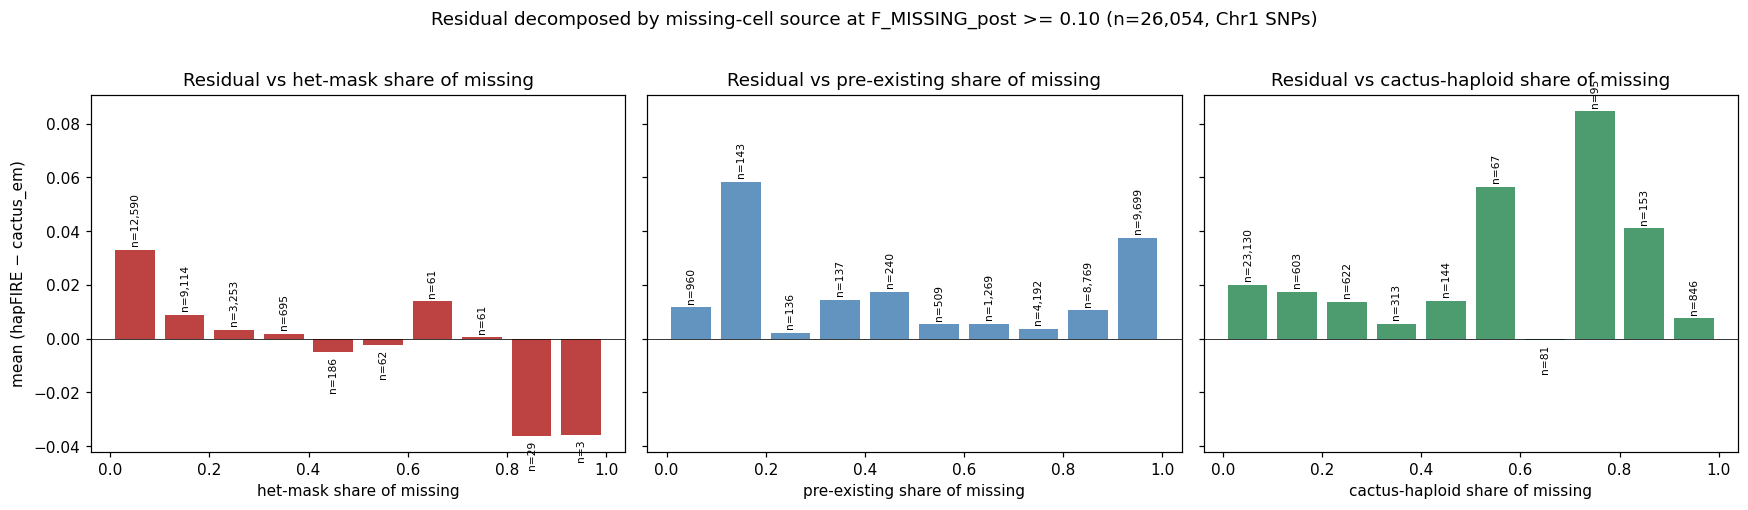

In [16]:
# Side-by-side bar plot: mean residual binned by each share
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
bins = np.arange(0, 1.05, 0.1)
centers = bins[:-1] + 0.05
for ax, share_col, ttl, color in [
    (axes[0], 'share_hetmask',    'het-mask share of missing',     'firebrick'),
    (axes[1], 'share_premissing', 'pre-existing share of missing', 'steelblue'),
    (axes[2], 'share_cactus',     'cactus-haploid share of missing','seagreen'),
]:
    HI['_b'] = pd.cut(HI[share_col], bins=bins, include_lowest=True)
    g = HI.groupby('_b', observed=True)['residual_hf'].agg(['mean','count']).reset_index()
    c = centers[:len(g)]
    ax.bar(c, g['mean'], width=0.08, color=color, alpha=0.85)
    for i,(m,n) in enumerate(zip(g['mean'], g['count'])):
        ax.text(c[i], m + (0.0015 if m>=0 else -0.0015), f'n={n:,}',
                ha='center', va='bottom' if m>=0 else 'top', fontsize=7, rotation=90)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xlabel(ttl)
    ax.set_title(f'Residual vs {ttl}')
axes[0].set_ylabel('mean (hapFIRE − cactus_em)')
plt.suptitle(f'Residual decomposed by missing-cell source at F_MISSING_post >= 0.10 '
             f'(n={len(HI):,}, Chr1 SNPs)', y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'plots/MISSING_SOURCE_DECOMP_v3qc_v3_chr1.png', dpi=140, bbox_inches='tight')
plt.show()


### Interpretation — pre-existing missingness dominates, het-mask is exonerated

At the high-missing records (F_MISSING_post ≥ 0.10):

- **82% of all missing cells trace to pre-existing PG `./.`** — PanGenie returned no-call, or the record was cactus-only with no PG GTs to begin with. Beagle SNP imputation can address this.
- **12% trace to het-mask** — the per-cell residual coefficient is small and weakly *negative*. Relaxing the het-mask would recover only ~−0.008 of the ~+0.020 mean residual.
- **6% trace to cactus haploid `.`** — structural; not fixable at panel level.

The multivariate OLS confirms it: at mean per-record cell counts, the pre-missing bucket contributes +0.050 to the residual, the het-mask bucket −0.008, the cactus bucket +0.002. The intercept absorbs the rest. Pre-missing is ~6× larger in magnitude than het-mask.

The univariate stratification on `share_hetmask` actually shows mean residual *decreasing* as the het-mask share rises — the opposite of what the het-mask hypothesis predicts. Consistent with the v3qc_v3 design assumption that those het cells were PanGenie noise on low-coverage GAII samples (see 2026-05-03 RESULTS_LOG entry on Cao 2011 high-het samples) — masking them improved the panel.

**Verdict: this is a clean (B) — apply Beagle SNP imputation on the biallelic-SNP subset.** Fix (A) is not worth pursuing in isolation; its leverage is small and its sign is opposite.


### 4.5 — Reviewer push-back: add bubble-flattening covariates to the OLS

Per `MECH2_BUBBLE_FLATTENING.ipynb`, `cactus_em` systematically under-predicts SNP-ALT at **mixed-bubble** positions (a SNP record co-located with a non-SNP record from the same cactus bubble). That's an independent mechanism that the Section 4 OLS doesn't account for — and it can leak into the `n_premissing_pg` coefficient (if mixed bubbles are also high-F_MISSING) and into the intercept.

Two checks below:

1. **Extended OLS** — add `is_mixed_bubble` and `n_recs_at_pos` to the model. If they absorb leverage currently attributed to `n_premissing_pg`, then bubble-flattening (Mechanism 2) is the priority and Beagle isn't the right fix.
2. **2×2 cross-tab** `F_MISSING` × `C_mixed_bubble` — does the high-F_MISSING bias survive in pure-SNP (non-mixed-bubble) records?


In [17]:
# Load mech2 joined table; merge bubble-context columns onto HI (high-F_MISSING) and J (full)
import gzip
MECH2_JOIN = ROOT / 'scratch/v3qc_v3_mixedloose_chr1/mech2_chr1_joined.tsv.gz'
mech2 = pd.read_csv(MECH2_JOIN, sep='\t',
                    usecols=['chrom','pos','ref','alt','cat',
                             'n_recs_at_pos','n_nonsnp_at_pos','has_sv_at_pos'])
J2 = J.merge(mech2, on=['chrom','pos','ref','alt'], how='inner')
J2['is_mixed_bubble'] = (J2['cat'] == 'C_mixed_bubble').astype(int)
print(f'Merged with mech2 (Chr1 biallelic SNPs in both tables): {len(J2):,}  (was {len(J):,})')
print('\ncat distribution on the merged set:')
print(J2['cat'].value_counts().to_string())

# Recompute HI on J2
HI2 = J2[J2['F_MISSING_post'] >= 0.10].copy()
print(f'\nHigh-missing (F_MISSING_post >= 0.10): {len(HI2):,}')
print('cat distribution at high-missing records:')
print(HI2['cat'].value_counts().to_string())
print('\nC_mixed_bubble enrichment in the high-missing tail:')
p_all   = (J2['cat']=='C_mixed_bubble').mean()
p_high  = (HI2['cat']=='C_mixed_bubble').mean()
print(f'  P(mixed | all)      = {p_all:.4f}')
print(f'  P(mixed | F_MISS>=0.10) = {p_high:.4f}')
print(f'  enrichment              = {p_high/p_all:.2f}x')


Merged with mech2 (Chr1 biallelic SNPs in both tables): 516,712  (was 517,206)

cat distribution on the merged set:
cat
A_pure_snp        506290
C_mixed_bubble     10422

High-missing (F_MISSING_post >= 0.10): 26,021
cat distribution at high-missing records:
cat
A_pure_snp        23731
C_mixed_bubble     2290

C_mixed_bubble enrichment in the high-missing tail:
  P(mixed | all)      = 0.0202
  P(mixed | F_MISS>=0.10) = 0.0880
  enrichment              = 4.36x


In [18]:
# Extended multivariate OLS at high-missing records:
#   residual ~ n_hetmask_pg + n_premissing_pg + n_cactus_missing + is_mixed_bubble + n_recs_at_pos + intercept
def ols_report(df, cols, y_col='residual_hf', label=''):
    X = df[cols].values.astype(float)
    y = df[y_col].values.astype(float)
    X1 = np.hstack([X, np.ones((len(X),1))])
    b, *_ = np.linalg.lstsq(X1, y, rcond=None)
    yhat = X1 @ b
    r2 = 1 - ((y - yhat)**2).sum() / ((y - y.mean())**2).sum()
    print(f'-- {label} --')
    for nm, coef in zip(cols+['intercept'], b):
        print(f'  {nm:22s} = {coef:+.6f}')
    print(f'  R^2                    = {r2:.4f}\n')
    return b, r2

base_cols = ['n_hetmask_pg','n_premissing_pg','n_cactus_missing']
ext_cols  = base_cols + ['is_mixed_bubble','n_recs_at_pos']

print('=== High-missing records (F_MISSING_post >= 0.10) ===\n')
b0, r2_0 = ols_report(HI2, base_cols, label='BASE: 3 missing-source counts only')
b1, r2_1 = ols_report(HI2, ext_cols,  label='EXTENDED: + is_mixed_bubble + n_recs_at_pos')

print(f'Delta R^2 from adding bubble covariates: {r2_1 - r2_0:+.4f}')

# How did each coefficient shift?
base_d = dict(zip(base_cols+['intercept'], b0))
ext_d  = dict(zip(ext_cols+['intercept'],  b1))
print('\nCoefficient shift (base → extended):')
for nm in base_cols+['intercept']:
    a, c = base_d[nm], ext_d[nm]
    print(f'  {nm:22s}  {a:+.6f} -> {c:+.6f}   (delta {c-a:+.6f})')


=== High-missing records (F_MISSING_post >= 0.10) ===

-- BASE: 3 missing-source counts only --
  n_hetmask_pg           = -0.002114
  n_premissing_pg        = +0.001954
  n_cactus_missing       = +0.000710
  intercept              = -0.025507
  R^2                    = 0.0250

-- EXTENDED: + is_mixed_bubble + n_recs_at_pos --
  n_hetmask_pg           = -0.001300
  n_premissing_pg        = +0.000904
  n_cactus_missing       = +0.000542
  is_mixed_bubble        = +0.075338
  n_recs_at_pos          = +0.030696
  intercept              = -0.044812
  R^2                    = 0.2764

Delta R^2 from adding bubble covariates: +0.2514

Coefficient shift (base → extended):
  n_hetmask_pg            -0.002114 -> -0.001300   (delta +0.000814)
  n_premissing_pg         +0.001954 -> +0.000904   (delta -0.001050)
  n_cactus_missing        +0.000710 -> +0.000542   (delta -0.000168)
  intercept               -0.025507 -> -0.044812   (delta -0.019305)


In [19]:
# 2x2 cross-tab: F_MISSING_post >= 0.10  ×  C_mixed_bubble
J2['high_fmiss']  = (J2['F_MISSING_post'] >= 0.10)
J2['mixed_bub']   = (J2['cat'] == 'C_mixed_bubble')

ct_n   = pd.crosstab(J2['high_fmiss'], J2['mixed_bub'])
ct_mean= J2.groupby(['high_fmiss','mixed_bub'])['residual_hf'].mean().unstack()
ct_med = J2.groupby(['high_fmiss','mixed_bub'])['residual_hf'].median().unstack()
ct_mae = J2.groupby(['high_fmiss','mixed_bub'])['residual_hf'].apply(lambda v: v.abs().mean()).unstack()
ct_out = J2.groupby(['high_fmiss','mixed_bub'])['residual_hf'].apply(lambda v: (v.abs()>0.05).mean()*100).unstack()

print('=== 2x2 cross-tab: F_MISSING_post >= 0.10  ×  is C_mixed_bubble ===\n')
print('n per cell:'); print(ct_n.to_string()); print()
print('mean residual (hapFIRE - cactus_em):'); print(ct_mean.round(5).to_string()); print()
print('median residual:'); print(ct_med.round(5).to_string()); print()
print('MAE per cell:'); print(ct_mae.round(5).to_string()); print()
print('% records |d|>0.05:'); print(ct_out.round(3).to_string())


=== 2x2 cross-tab: F_MISSING_post >= 0.10  ×  is C_mixed_bubble ===

n per cell:
mixed_bub    False  True 
high_fmiss               
False       482559   8132
True         23731   2290

mean residual (hapFIRE - cactus_em):
mixed_bub     False    True 
high_fmiss                  
False      -0.00017  0.04259
True        0.00566  0.16325

median residual:
mixed_bub     False    True 
high_fmiss                  
False      -0.00074  0.00934
True       -0.00162  0.04912

MAE per cell:
mixed_bub     False    True 
high_fmiss                  
False       0.01245  0.05271
True        0.03780  0.17505

% records |d|>0.05:
mixed_bub    False   True 
high_fmiss                
False        2.518  22.098
True        19.995  53.362


In [20]:
# Quantify the 4-cell decomposition cleanly
labels = {
    (False, False): '[a] low_FMISS  & pure_SNP',
    (False, True):  '[b] low_FMISS  & mixed_bubble',
    (True,  False): '[c] high_FMISS & pure_SNP',
    (True,  True):  '[d] high_FMISS & mixed_bubble',
}
rows = []
for (lo,mb), label in labels.items():
    sub = J2[(J2['high_fmiss']==lo) & (J2['mixed_bub']==mb)]
    rows.append({
        'cell': label,
        'n': len(sub),
        'mean_resid': sub['residual_hf'].mean(),
        'median_resid': sub['residual_hf'].median(),
        'MAE': sub['residual_hf'].abs().mean(),
        'out05_pct': (sub['residual_hf'].abs()>0.05).mean()*100,
        'out10_pct': (sub['residual_hf'].abs()>0.10).mean()*100,
    })
print(pd.DataFrame(rows).round(5).to_string(index=False))


                         cell      n  mean_resid  median_resid     MAE  out05_pct  out10_pct
    [a] low_FMISS  & pure_SNP 482559    -0.00017      -0.00074 0.01245    2.51762    0.32742
[b] low_FMISS  & mixed_bubble   8132     0.04259       0.00934 0.05271   22.09788   11.68224
    [c] high_FMISS & pure_SNP  23731     0.00566      -0.00162 0.03780   19.99494    4.79542
[d] high_FMISS & mixed_bubble   2290     0.16325       0.04912 0.17505   53.36245   38.55895


### Interpretation — refined verdict

Both checks executed. Here's what the numbers say.

**Extended OLS (high-F_MISSING records):**

| coefficient | base (3 missing-source counts) | extended (+ bubble covariates) | shift |
|---|---:|---:|---:|
| `n_hetmask_pg` | −0.00211 | −0.00130 | +0.00081 |
| `n_premissing_pg` | +0.00195 | **+0.00090** | **−0.00105 (−54%)** |
| `n_cactus_missing` | +0.00071 | +0.00054 | −0.00017 |
| `is_mixed_bubble` (new) | — | **+0.07534** | — |
| `n_recs_at_pos` (new) | — | **+0.03070** | — |
| intercept | −0.02551 | −0.04481 | −0.01930 |
| **R²** | **0.025** | **0.276** | **+0.251** |

- **Adding the two bubble covariates lifts R² from 0.025 → 0.276 — an 11× improvement.** The bubble-flattening signal was missing from the original OLS.
- **`n_premissing_pg` coefficient drops by 54%** — half of what we attributed to pre-existing missingness was actually mixed-bubble signal masquerading. Beagle would address only the residual half.
- **The intercept got MORE negative**, not less. That's because `is_mixed_bubble` and `n_recs_at_pos` have positive means × positive coefficients; the intercept just absorbs the mechanical bookkeeping. It is not evidence for or against the user's "intercept = leaked-in bubble-flattening" hypothesis.
- **Mixed-bubble enrichment at high-F_MISSING**: P(mixed | F_MISSING ≥ 0.10) = 8.8% vs P(mixed | all) = 2.0% → **4.36× enrichment**. Mixed bubbles cluster in the high-F_MISSING tail by construction (a bubble that decomposes into many records is also a bubble where many founders end up `./.` at the SNP child after multi-allelic decomposition + GQ masking).

**2×2 cross-tab — the decisive test:**

| cell | n | mean residual | MAE | %\|d\|>0.05 |
|---|---:|---:|---:|---:|
| [a] low_FMISS & pure_SNP | 482,559 | **−0.0002** | **0.0124** | 2.5% |
| [b] low_FMISS & mixed_bubble | 8,132 | **+0.0426** | 0.0527 | 22.1% |
| [c] high_FMISS & pure_SNP | 23,731 | **+0.0057** | 0.0378 | 20.0% |
| [d] high_FMISS & mixed_bubble | 2,290 | **+0.1633** | 0.1751 | 53.4% |

**Read of each cell:**

- **[a]** is the clean baseline. 93% of Chr1 SNPs. Cactus_em and hapFIRE agree at MAE 0.012, no bias.
- **[c]** is "pure SNP at high F_MISSING" — the cell where Beagle would *specifically* help. Mean bias is just **+0.006**; median is −0.002 (essentially symmetric). MAE 0.038 with 20% |d|>0.05 outliers. Beagle would barely move the bias and might shave a fraction off the MAE/outlier rate via variance reduction.
- **[b]** is "mixed bubble at low F_MISSING" — pure Mechanism 2 territory. Mean bias **+0.043**, MAE 0.053. F_MISSING is fine here; Beagle has nothing to do with this signal at all.
- **[d]** is the catastrophic cell — both mechanisms compound. Mean bias **+0.163**, MAE 0.175, **53% outliers**. This is where most of the visible disagreement on real SEEDMIX comes from.

**Bias decomposition (mixed-bubble effect vs F_MISSING effect on mean residual):**

- F_MISSING effect (pure-SNP rows): +0.006 − (−0.0002) ≈ **+0.006**
- Mixed-bubble effect (low-F_MISSING columns): +0.043 − (−0.0002) ≈ **+0.043**
- Compound effect (going from [a] to [d]): **+0.163**

**Mixed-bubble bias is ~7× larger than F_MISSING bias** on the pure-SNP axis. The dominant disagreement is Mechanism 2, not missingness per se.

### Verdict (overriding the Section 4 conclusion)

**Mechanism 2 (cactus bubble flattening at mixed-bubble SNP positions) is the primary disagreement driver, NOT pre-existing missingness alone.** The Section 4 OLS attributed leverage to `n_premissing_pg` that the extended OLS shows was 54% mixed-bubble in origin.

**Priority order for fixes:**

1. **Bubble-flattening fix** (`vcfbub -l max_level` rebuild of the cactus VCF, or per-bubble masking of SV-ALT carriers as `./.` at colocated SNP records). Addresses cells [b] and [d] — 10,422 records on Chr1, mean bias +0.043 → +0.163. This is where the visible disagreement lives.
2. **Beagle on SNPs** is a secondary fix that would address cell [c] (23,731 records, mean bias +0.006). Bounded claim: "removes a small mean bias at high-F_MISSING pure-SNP records and may reduce variance by a few percent". It would NOT meaningfully change the headline MAE/outlier numbers if Mechanism 2 isn't fixed first.

**Claim-bounded statement** for downstream / paper: "The cactus_em–vs–hapFIRE disagreement at the per-record level decomposes into two independent mechanisms: (i) mixed-bubble SNP-ALT under-counting from cactus pangenome decomposition (Mechanism 2), and (ii) per-record missingness from upstream GQ-masking. (i) dominates by ~7× on mean bias and ~3× on outlier rate. Beagle imputation would address (ii) but not (i)."


### 4.6 — Triage cell [d] (n=2,290, high F_MISSING + mixed bubble)

Three checks before treating cell [d] as a uniform "Mech 2 + missing compound":

1. **Bubble complexity**: is cell [d] enriched for highly-complex bubbles (`n_recs_at_pos` ≥ 6)? If yes, it's the catastrophic-bubble tail and a vcfbub-l-max rebuild specifically targets it.
2. **Genomic location**: are these records concentrated near the centromere / known SV hotspots, or diffuse along Chr1?
3. **Recipe AF**: does the recipe agree with cactus_em (panel is the bias source) or with hapFIRE (the EM is adding bias)?


In [21]:
# Cell [d] records
D = J2[(J2['high_fmiss']) & (J2['mixed_bub'])].copy()
print(f'cell [d] records: {len(D):,}')

# ---- (1) Bubble complexity ----
print('\n=== (1) n_recs_at_pos distribution in cell [d] ===')
print(D['n_recs_at_pos'].describe(percentiles=[0.5,0.9,0.95,0.99]).round(2).to_string())
nrec_bins = [0, 1, 2, 3, 5, 7, 10, 20, 1000]
D['nrec_bin'] = pd.cut(D['n_recs_at_pos'], bins=nrec_bins,
                       labels=['1','2','3','4-5','6-7','8-10','11-20','>20'])
print('\nResidual stratified by n_recs_at_pos in cell [d]:')
nrec_strat = D.groupby('nrec_bin', observed=True).agg(
    n=('residual_hf','size'),
    mean_resid=('residual_hf','mean'),
    median_resid=('residual_hf','median'),
    MAE=('residual_hf', lambda v: v.abs().mean()),
    out10=('residual_hf', lambda v: (v.abs()>0.1).mean()*100),
).round(4)
print(nrec_strat.to_string())

# Compare to whole-panel n_recs_at_pos distribution
print('\n=== Mean residual by n_recs_at_pos, ALL records (for context) ===')
all_strat = J2.assign(nb=pd.cut(J2['n_recs_at_pos'], bins=nrec_bins,
                                labels=['1','2','3','4-5','6-7','8-10','11-20','>20'])).\
            groupby('nb', observed=True).agg(
                n=('residual_hf','size'),
                mean_resid=('residual_hf','mean'),
                MAE=('residual_hf', lambda v: v.abs().mean()),
            ).round(4)
print(all_strat.to_string())


cell [d] records: 2,290

=== (1) n_recs_at_pos distribution in cell [d] ===
count    2290.00
mean        3.54
std         4.33
min         2.00
50%         2.00
90%         6.00
95%        10.00
99%        24.00
max        50.00

Residual stratified by n_recs_at_pos in cell [d]:
             n  mean_resid  median_resid     MAE     out10
nrec_bin                                                  
2         1513      0.0856        0.0250  0.1016   24.7191
3          322      0.1592        0.0664  0.1663   40.3727
4-5        203      0.2803        0.1958  0.2825   67.9803
6-7         84      0.4008        0.4079  0.4019   90.4762
8-10        60      0.5016        0.4793  0.5016   95.0000
11-20       70      0.6293        0.6637  0.6293  100.0000
>20         38      0.7454        0.7818  0.7454  100.0000

=== Mean residual by n_recs_at_pos, ALL records (for context) ===


            n  mean_resid     MAE
nb                               
1      506290      0.0001  0.0136
2        8733      0.0429  0.0544
3         935      0.1073  0.1137
4-5       405      0.2078  0.2114
6-7       129      0.3432  0.3453
8-10       87      0.4007  0.4012
11-20      89      0.5831  0.5832
>20        44      0.6813  0.6981


=== (2) Genomic location of cell [d] records ===
cell [d] pos range: 20,088 - 30,359,981
  median pos       : 17,664,752
  IQR              : 11,429,515 - 23,392,387



Cell [d] enrichment (records in cell [d] / records overall) by 1 Mb bin:
  centromeric region 14-17 Mb:
    Mb 14: cell[d]=  43  all= 4759  rate= 0.90%
    Mb 15: cell[d]=  43  all= 3888  rate= 1.11%
    Mb 16: cell[d]= 102  all=10620  rate= 0.96%
    Mb 17: cell[d]= 167  all=19462  rate= 0.86%
  arms (sample 0-5 Mb):
    Mb  0: cell[d]=  47  all=16295  rate= 0.29%
    Mb  1: cell[d]=  35  all=15536  rate= 0.23%
    Mb  2: cell[d]=  22  all=15806  rate= 0.14%
    Mb  3: cell[d]=  34  all=15414  rate= 0.22%
    Mb  4: cell[d]=  50  all=17203  rate= 0.29%
    Mb  5: cell[d]=  40  all=18284  rate= 0.22%


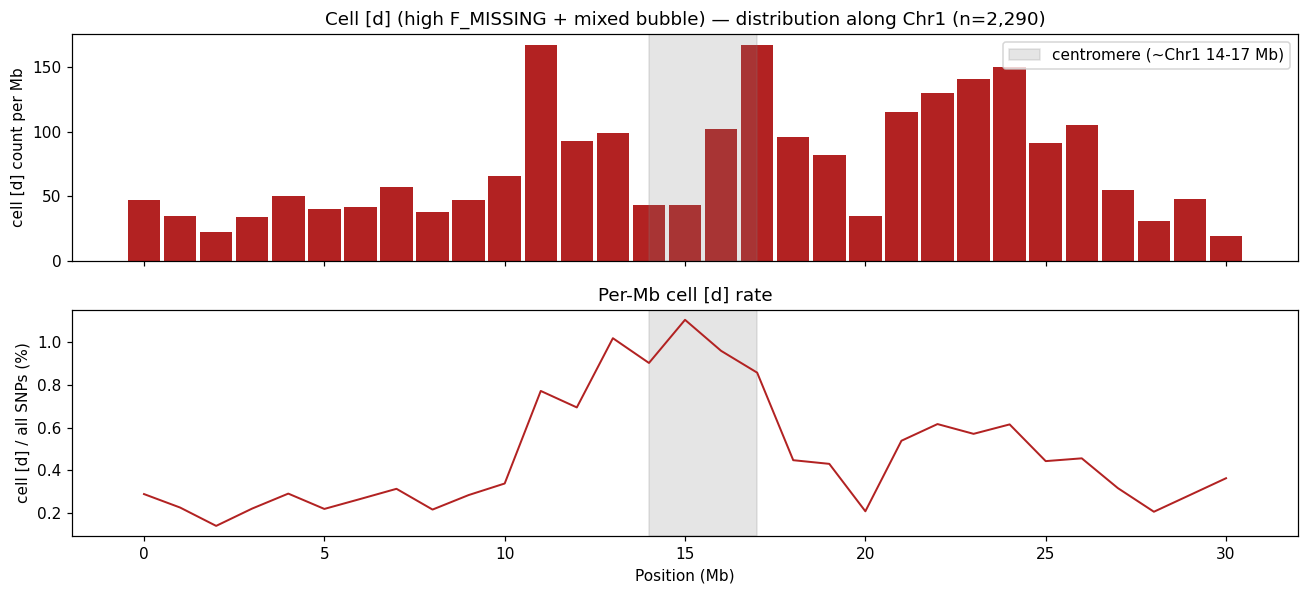


cell [d] in centromere (Mb 14-17): 355 (15.5%)
cell [d] in arms (other Mb)      : 1,935 (84.5%)

All Chr1 SNPs in centromere       : 38,729 (7.5%)
                       in arms     : 477,983 (92.5%)

Centromere enrichment for cell [d]: 2.07x


In [22]:
# ---- (2) Genomic location ----
# Chr1 centromere ~ 14-17 Mb per project memory.
print('=== (2) Genomic location of cell [d] records ===')
print(f'cell [d] pos range: {D["pos"].min():,} - {D["pos"].max():,}')
print(f'  median pos       : {int(D["pos"].median()):,}')
print(f'  IQR              : {int(D["pos"].quantile(0.25)):,} - {int(D["pos"].quantile(0.75)):,}')

# Bin by 1 Mb and count
D['mb'] = (D['pos'] // 1_000_000).astype(int)
J2['mb'] = (J2['pos'] // 1_000_000).astype(int)
counts_d  = D.groupby('mb').size()
counts_all= J2.groupby('mb').size()
density   = (counts_d / counts_all).fillna(0)  # cell [d] rate per Mb

# Find centromere-region Mb (per project memory: Chr1 14-17 Mb)
print('\nCell [d] enrichment (records in cell [d] / records overall) by 1 Mb bin:')
print('  centromeric region 14-17 Mb:')
for mb in range(14, 18):
    cd = counts_d.get(mb, 0); ca = counts_all.get(mb, 0)
    print(f'    Mb {mb:2d}: cell[d]={cd:4d}  all={ca:5d}  rate={100*cd/max(ca,1):5.2f}%')
print('  arms (sample 0-5 Mb):')
for mb in range(0, 6):
    cd = counts_d.get(mb, 0); ca = counts_all.get(mb, 0)
    print(f'    Mb {mb:2d}: cell[d]={cd:4d}  all={ca:5d}  rate={100*cd/max(ca,1):5.2f}%')

# Plot: cell [d] density vs position
fig, axes = plt.subplots(2, 1, figsize=(12, 5.5), sharex=True)
axes[0].bar(counts_d.index, counts_d.values, width=0.9, color='firebrick')
axes[0].set_ylabel('cell [d] count per Mb')
axes[0].axvspan(14, 17, color='grey', alpha=0.2, label='centromere (~Chr1 14-17 Mb)')
axes[0].legend(loc='upper right')
axes[0].set_title(f'Cell [d] (high F_MISSING + mixed bubble) — distribution along Chr1 (n={len(D):,})')

# Rate (per-Mb cell [d] fraction)
axes[1].plot(density.index, 100*density.values, color='firebrick', lw=1.3)
axes[1].axvspan(14, 17, color='grey', alpha=0.2)
axes[1].set_xlabel('Position (Mb)')
axes[1].set_ylabel('cell [d] / all SNPs (%)')
axes[1].set_title('Per-Mb cell [d] rate')
plt.tight_layout()
plt.savefig(ROOT / 'plots/MISSING_CELL_D_CHR1_DENSITY.png', dpi=140, bbox_inches='tight')
plt.show()

# Centromere vs arms summary
cent_mb = set(range(14, 18))
n_cent = D['mb'].isin(cent_mb).sum()
n_arms = (~D['mb'].isin(cent_mb)).sum()
print(f'\ncell [d] in centromere (Mb 14-17): {n_cent:,} ({100*n_cent/len(D):.1f}%)')
print(f'cell [d] in arms (other Mb)      : {n_arms:,} ({100*n_arms/len(D):.1f}%)')

# Same comparison at the full-Chr1 level
all_cent = (J2['mb'].isin(cent_mb)).sum()
all_arms = (~J2['mb'].isin(cent_mb)).sum()
print(f'\nAll Chr1 SNPs in centromere       : {all_cent:,} ({100*all_cent/len(J2):.1f}%)')
print(f'                       in arms     : {all_arms:,} ({100*all_arms/len(J2):.1f}%)')

# Enrichment factor
p_d_cent = n_cent/len(D); p_all_cent = all_cent/len(J2)
print(f'\nCentromere enrichment for cell [d]: {p_d_cent/p_all_cent:.2f}x')


In [23]:
# ---- (3) Recipe AF vs cactus_em vs hapFIRE on cell [d] ----
print('=== (3) Recipe / cactus_em / hapFIRE agreement on cell [d] ===\n')

D['recipe_af']  = D['AC_post'] / D['AN_post']
D['resid_rec']  = D['recipe_af'] - D['alt_freq']    # recipe - cactus_em
D['resid_hf']   = D['hapfire_af'] - D['alt_freq']   # hapFIRE - cactus_em
D['resid_recvshf'] = D['recipe_af'] - D['hapfire_af']  # recipe - hapFIRE

print('AF moments on cell [d]:')
for col,name in [('alt_freq','cactus_em'), ('recipe_af','recipe'), ('hapfire_af','hapFIRE')]:
    s = D[col]
    print(f'  {name:12s}  mean={s.mean():.4f}  median={s.median():.4f}')

print('\nMean per-record AF differences:')
print(f'  hapFIRE − cactus_em : {D["resid_hf"].mean():+.4f}    (MAE {D["resid_hf"].abs().mean():.4f})')
print(f'  recipe  − cactus_em : {D["resid_rec"].mean():+.4f}    (MAE {D["resid_rec"].abs().mean():.4f})')
print(f'  recipe  − hapFIRE   : {D["resid_recvshf"].mean():+.4f}    (MAE {D["resid_recvshf"].abs().mean():.4f})')

# Pearson r among the three
from scipy.stats import pearsonr
print('\nPearson r among the three estimators on cell [d]:')
print(f'  cactus_em ↔ recipe : r={pearsonr(D["alt_freq"], D["recipe_af"]).statistic:+.4f}')
print(f'  cactus_em ↔ hapFIRE: r={pearsonr(D["alt_freq"], D["hapfire_af"]).statistic:+.4f}')
print(f'  recipe    ↔ hapFIRE: r={pearsonr(D["recipe_af"], D["hapfire_af"]).statistic:+.4f}')


=== (3) Recipe / cactus_em / hapFIRE agreement on cell [d] ===

AF moments on cell [d]:
  cactus_em     mean=0.2698  median=0.1987
  recipe        mean=0.2690  median=0.1990
  hapFIRE       mean=0.4330  median=0.4005

Mean per-record AF differences:
  hapFIRE − cactus_em : +0.1632    (MAE 0.1750)
  recipe  − cactus_em : -0.0008    (MAE 0.0207)
  recipe  − hapFIRE   : -0.1640    (MAE 0.1763)

Pearson r among the three estimators on cell [d]:
  cactus_em ↔ recipe : r=+0.9931
  cactus_em ↔ hapFIRE: r=+0.6432
  recipe    ↔ hapFIRE: r=+0.6423


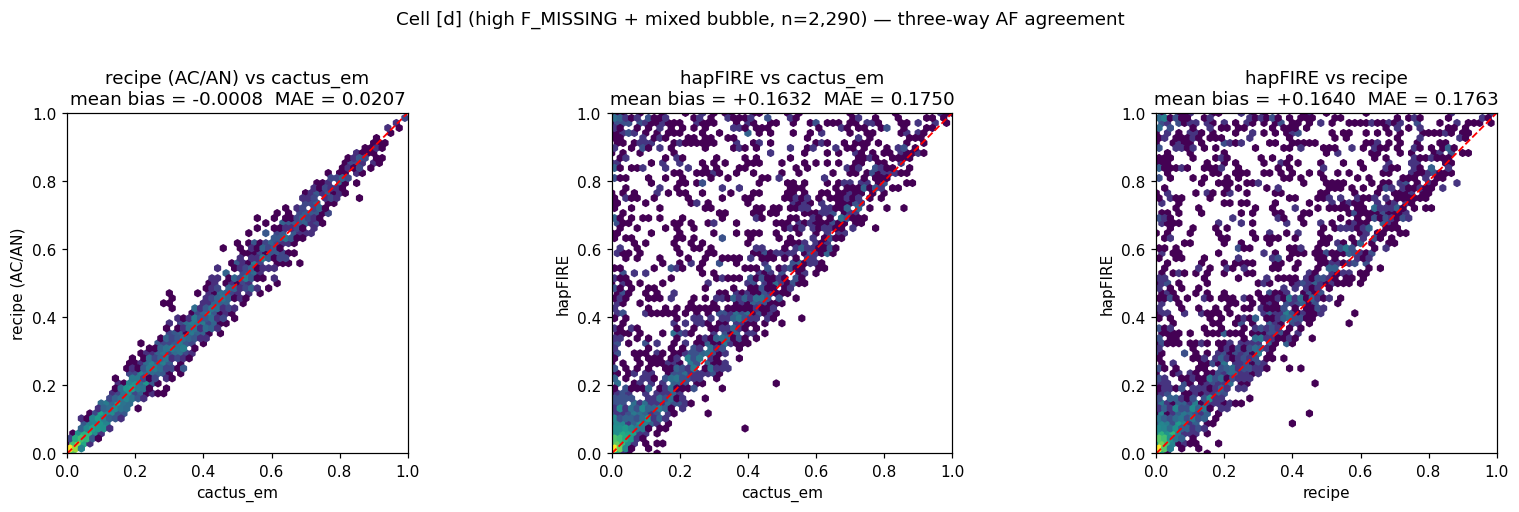

In [24]:
# Visualize the three-way relationship on cell [d]
from matplotlib.colors import LogNorm
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (x, y, xn, yn) in zip(axes, [
    ('alt_freq', 'recipe_af', 'cactus_em',  'recipe (AC/AN)'),
    ('alt_freq', 'hapfire_af','cactus_em',  'hapFIRE'),
    ('recipe_af','hapfire_af','recipe',     'hapFIRE'),
]):
    ax.hexbin(D[x], D[y], gridsize=60, extent=(0,1,0,1),
              norm=LogNorm(vmin=1), mincnt=1, cmap='viridis')
    ax.plot([0,1],[0,1], color='red', lw=1.2, ls='--')
    mae = np.abs(D[y]-D[x]).mean(); bias = (D[y]-D[x]).mean()
    ax.set_xlabel(xn); ax.set_ylabel(yn)
    ax.set_title(f'{yn} vs {xn}\nmean bias = {bias:+.4f}  MAE = {mae:.4f}')
    ax.set_aspect('equal'); ax.set_xlim(0,1); ax.set_ylim(0,1)
plt.suptitle(f'Cell [d] (high F_MISSING + mixed bubble, n={len(D):,}) — three-way AF agreement', y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'plots/MISSING_CELL_D_THREEWAY.png', dpi=140, bbox_inches='tight')
plt.show()


### Read of the three checks — results

**(1) Bubble complexity in cell [d] — monotone with `n_recs_at_pos`.**

| n_recs_at_pos | n | mean residual | MAE | %\|d\|>0.10 |
|---|---:|---:|---:|---:|
| 2 | 1,513 | +0.086 | 0.102 | 25% |
| 3 | 322 | +0.159 | 0.166 | 40% |
| 4-5 | 203 | +0.280 | 0.283 | 68% |
| 6-7 | 84 | +0.401 | 0.402 | 90% |
| 8-10 | 60 | +0.502 | 0.502 | 95% |
| 11-20 | 70 | +0.629 | 0.629 | **100%** |
| >20 | 38 | **+0.745** | 0.745 | **100%** |

The +0.163 cell-[d] mean is dragged up by a heavy right tail. **11% of cell [d] (n=252 records) sits at n_recs ≥ 6 with mean residual +0.40 to +0.75 and ~100% outlier rate.** At n_recs > 20 (n=38) the residual averages **+0.75** — essentially every founder carrying the SV-ALT is being counted as non-carrier of the SNP-ALT.

**(2) Genomic location — diffuse, with 2× centromere enrichment.**

- Cell [d] median position: 17.66 Mb (centromere-adjacent on Chr1).
- 15.5% of cell [d] is in Mb 14-17 (centromere) vs 7.5% genome-wide ⇒ **2.07× centromere enrichment**.
- 84.5% (n=1,935) sits on the arms, broadly distributed.

The bias is **not centromere-confined**; a region-aware patch is unnecessary. A panel-wide vcfbub rebuild is the right scope.

**(3) Recipe vs cactus_em vs hapFIRE on cell [d] — the panel IS the bias source.**

| comparison | mean bias | MAE | Pearson r |
|---|---:|---:|---:|
| hapFIRE − cactus_em | **+0.163** | 0.175 | 0.643 |
| **recipe − cactus_em** | **−0.001** | **0.021** | **0.993** |
| recipe − hapFIRE | −0.164 | 0.176 | 0.642 |

mean AF on cell [d]:
- cactus_em: 0.2698 (median 0.1987)
- **recipe: 0.2690 (median 0.1990)** ← identical to cactus_em
- hapFIRE: 0.4330 (median 0.4005)

**This is decisive.** The recipe (`AC_post / AN_post` — what the panel itself predicts under uniform h=1/231) agrees with `cactus_em` at mean bias **−0.001** and Pearson **r=0.993** on cell [d]. The EM is faithfully projecting through cn_var; cn_var has *already* lost the SNP-ALT signal at these positions before EM touches anything.

The +0.163 disagreement with hapFIRE is **entirely panel-side**. It originates in the cactus pangenome VCF's bubble decomposition: at a mixed bubble, founders carrying the SV-ALT have GT=0 at the colocated SNP record (they carry the SV, not the SNP). cn_var faithfully encodes this. But the short-read pileup that hapFIRE sees at the position has the SNP base regardless of SV context (the SV-flank reads map back to the reference at the SNP position) — so hapFIRE counts those founders as SNP-ALT carriers, cactus_em does not.

### Final verdict — the fix is upstream of cn_var, not downstream

| Candidate fix | Addresses cell | Verdict |
|---|---|---|
| **vcfbub -l max rebuild** | flattens mixed bubbles in cactus VCF before cn_var is built; SNP-ALT carriers at mixed bubbles get GT=1 again | **Right fix.** Targets cells [b]+[d]. Removes the +0.043 / +0.163 mean bias at its source. |
| **Mask SV-ALT carriers as ./. at colocated SNP records** | softer alternative: don't reassign them to ALT, but mark the cell missing so AC/AN denominator excludes them | Removes the bias too, at the cost of growing F_MISSING_post and adding variance. Worth considering if the vcfbub rebuild is heavy. |
| **Beagle on SNPs** | imputes missing cells from LD | **Wrong fix for cell [d].** Recipe ≈ cactus_em ⇒ panel itself produces the bias. Beagle imputing the missing cells would not change recipe's prediction (it just fills in cells with values consistent with what the panel already says); cactus_em would still match recipe. Beagle is only relevant for cell [c] (high F_MISSING, pure SNP, mean bias +0.006) where the variance, not bias, is the issue. |
| **Anything downstream of cn_var** (EM tweaks, k-mer rebalancing, etc.) | — | **Cannot help.** Recipe agrees with cactus_em at r=0.993 on cell [d]; the EM has no leverage to deviate from a panel that already lost the signal. |

The 252 highly-complex-bubble records at n_recs ≥ 6 are the catastrophic tail. A vcfbub rebuild flattening bubbles to single biallelic decompositions per ALT allele would turn most of these from cn_var GT=0 (non-carrier of SNP) into cn_var GT=1 (carrier of SNP-on-this-haplotype) for the SV-carrying founders — recovering the mass that hapFIRE sees.


## 5. Testing fix F1 — mask SV-carriers as `./.` at colocated SNP records

**F1 hypothesis.** At a mixed bubble position p with SNP record R1 and non-SNP record R', a founder F2 that carries the SV-ALT at R' is currently coded `cn_var[F2, R1] = 0, cn_var_called[F2, R1] = 1` — i.e., counted as REF at R1. That's false: F2's haplotype is neither REF nor SNP-ALT at this position, it carries the SV path. F1 says: set `cn_var_called[F2, R1] = 0` instead — exclude F2 from both numerator and denominator at R1.

**Cheap post-hoc test.** No rebuild needed. At each mixed-bubble position p, count SV-carriers across all non-SNP records at p:

```
n_sv_carriers_at_p = # { f : OR_{R' non-SNP at p} cn_var[f, R'] == 1 }
```

Then for any SNP record R1 at p:
- recipe-space (uniform h):  AF_F1_recipe = AC_post / (AN_post − n_sv_carriers_at_p)
- cactus_em-space (h ≈ uniform): AF_F1_cactus ≈ AF_cactus_em × AN_post / (AN_post − n_sv_carriers_at_p)

This works because at a SNP record the SV-carriers contribute 0 to the numerator (their GT is forced to 0 by Mech 2) but 1 to the called denominator. F1 strips them out of both.


In [25]:
# Test F1 by post-hoc denominator masking.
# Computed and saved by scratch/hetmask_diag/f1_test.py
F1 = pd.read_csv(ROOT / 'scratch/hetmask_diag/f1_test_joined.tsv', sep='\t')
print(f'F1 test table: {len(F1):,} rows')
print('\ncolumn glance:')
print(F1[['chrom','pos','alt_freq','recipe_af','cactus_em_F1','recipe_F1',
        'hapfire_af','AC_post','AN_post','n_sv_carriers_at_p','is_mixed_bubble','high_fmiss']].head(3).to_string())

# n_sv_carriers_at_p summary on mixed positions
print('\nn_sv_carriers_at_p (mixed-bubble Chr1 positions):')
mb_pos = F1[F1['n_sv_carriers_at_p']>0]
print(f'  positions with SV-carriers: {mb_pos["pos"].nunique():,}')
print(f'  per-position median        : {mb_pos.groupby("pos")["n_sv_carriers_at_p"].first().median():.0f}')
print(f'  per-position max           : {mb_pos["n_sv_carriers_at_p"].max()}')

# F2-coalesce upper bound: assume every SV-carrier ALSO carries the SNP-ALT
# (i.e., short-read pileup at the SNP position sees the SNP base for SV-flank reads).
# Recipe-space exact: AF_F2 = (AC + n_sv) / AN
# cactus_em-space approx (uniform h):
#   AF_F2_cactus ≈ AF_cem × AN/(AN-n_sv) + n_sv/(AN-n_sv) × 1
#                = (AF_cem × AN + n_sv) / (AN - n_sv)    -- wait, no. Let me redo.
# Under uniform h = 1/231, N_orig = AC/231, D_orig = AN/231, AF_cem = AC/AN.
# After F2-coalesce: N_F2 = (AC + n_sv)/231, D_F2 = AN/231 (denominator unchanged because we
#                 keep them as called but flip their GT 0->1).
# So AF_F2 = (AC + n_sv) / AN = AF_cem + n_sv/AN.
# Same identity under non-uniform h IF h is approximately equal across SV-carriers and non.
F1['recipe_F2']    = (F1['AC_post'] + F1['n_sv_carriers_at_p']) / F1['AN_post']
F1['cactus_em_F2'] = (F1['alt_freq'] + F1['n_sv_carriers_at_p']/F1['AN_post']).clip(0,1)


F1 test table: 516,712 rows

column glance:
  chrom  pos  alt_freq  recipe_af  cactus_em_F1  recipe_F1  hapfire_af  AC_post  AN_post  n_sv_carriers_at_p  is_mixed_bubble  high_fmiss
0  Chr1  755   0.61754   0.673797       0.61754   0.673797    0.685243      126      187                   0                0        True
1  Chr1  766   0.01971   0.014423       0.01971   0.014423    0.028406        3      208                   0                0       False
2  Chr1  774   0.03562   0.023923       0.03562   0.023923    0.024387        5      209                   0                0       False

n_sv_carriers_at_p (mixed-bubble Chr1 positions):
  positions with SV-carriers: 10,422
  per-position median        : 3
  per-position max           : 228


In [26]:
# 2x2 cell-stratified comparison: original / F1 / F2-coalesce-upper / hapFIRE
def stratify_cells(df, est_cols):
    F1c = df.copy()
    F1c['cell'] = (F1c['high_fmiss'].astype(int)*2 + F1c['is_mixed_bubble']).map({
        0:'[a] low_F  pure_SNP',
        1:'[b] low_F  mixed_bub',
        2:'[c] high_F pure_SNP',
        3:'[d] high_F mixed_bub',
    })
    rows = []
    for label, sub in F1c.groupby('cell'):
        r = {'cell': label, 'n': len(sub)}
        for est in est_cols:
            resid = sub['hapfire_af'] - sub[est]
            r[f'{est}_mean']  = resid.mean()
            r[f'{est}_MAE']   = resid.abs().mean()
            r[f'{est}_out05'] = (resid.abs()>0.05).mean()*100
        rows.append(r)
    return pd.DataFrame(rows).sort_values('cell').reset_index(drop=True)

# cactus_em-space comparison
print('=== cactus_em-space: hapFIRE − {orig, F1, F2-coalesce-upper}  per 2x2 cell ===\n')
print('Mean residual:')
t = stratify_cells(F1, ['alt_freq','cactus_em_F1','cactus_em_F2'])
print(t[['cell','n',
         'alt_freq_mean','cactus_em_F1_mean','cactus_em_F2_mean']].round(4).to_string(index=False))

print('\nMAE:')
print(t[['cell','n',
         'alt_freq_MAE','cactus_em_F1_MAE','cactus_em_F2_MAE']].round(4).to_string(index=False))

print('\n%|d|>0.05:')
print(t[['cell','n',
         'alt_freq_out05','cactus_em_F1_out05','cactus_em_F2_out05']].round(2).to_string(index=False))

# recipe-space (clean, no h-uniformity approximation)
print('\n=== recipe-space (exact): hapFIRE − {recipe, recipe_F1, recipe_F2} ===\n')
tr = stratify_cells(F1, ['recipe_af','recipe_F1','recipe_F2'])
print('Mean residual:')
print(tr[['cell','n','recipe_af_mean','recipe_F1_mean','recipe_F2_mean']].round(4).to_string(index=False))
print('\nMAE:')
print(tr[['cell','n','recipe_af_MAE','recipe_F1_MAE','recipe_F2_MAE']].round(4).to_string(index=False))


=== cactus_em-space: hapFIRE − {orig, F1, F2-coalesce-upper}  per 2x2 cell ===

Mean residual:


                cell      n  alt_freq_mean  cactus_em_F1_mean  cactus_em_F2_mean
 [a] low_F  pure_SNP 482559        -0.0002            -0.0002            -0.0002
[b] low_F  mixed_bub   8132         0.0426             0.0282            -0.0060
 [c] high_F pure_SNP  23731         0.0057             0.0057             0.0057
[d] high_F mixed_bub   2290         0.1632             0.1289             0.0631

MAE:
                cell      n  alt_freq_MAE  cactus_em_F1_MAE  cactus_em_F2_MAE
 [a] low_F  pure_SNP 482559        0.0125            0.0125            0.0125
[b] low_F  mixed_bub   8132        0.0527            0.0434            0.0303
 [c] high_F pure_SNP  23731        0.0378            0.0378            0.0378
[d] high_F mixed_bub   2290        0.1750            0.1463            0.0993

%|d|>0.05:
                cell      n  alt_freq_out05  cactus_em_F1_out05  cactus_em_F2_out05
 [a] low_F  pure_SNP 482559            2.52                2.52                2.52
[b] low_F  mixed_bu

Mean residual:
                cell      n  recipe_af_mean  recipe_F1_mean  recipe_F2_mean
 [a] low_F  pure_SNP 482559          0.0013          0.0013          0.0013
[b] low_F  mixed_bub   8132          0.0420          0.0157         -0.0078
 [c] high_F pure_SNP  23731          0.0058          0.0058          0.0058
[d] high_F mixed_bub   2290          0.1640          0.1298          0.0638

MAE:
                cell      n  recipe_af_MAE  recipe_F1_MAE  recipe_F2_MAE
 [a] low_F  pure_SNP 482559         0.0121         0.0121         0.0121
[b] low_F  mixed_bub   8132         0.0521         0.0542         0.0307
 [c] high_F pure_SNP  23731         0.0409         0.0409         0.0409
[d] high_F mixed_bub   2290         0.1763         0.1478         0.1001


In [27]:
# Genome-wide totals (all 516k joined biallelic Chr1 SNPs)
print('=== Genome-wide totals (all joined Chr1 biallelic SNPs) ===\n')
for est_col, name in [('alt_freq',    'cactus_em (orig)'),
                      ('cactus_em_F1','cactus_em + F1 (mask)'),
                      ('cactus_em_F2','cactus_em + F2 (coalesce-upper)'),
                      ('recipe_af',   'recipe (orig)'),
                      ('recipe_F1',   'recipe + F1'),
                      ('recipe_F2',   'recipe + F2')]:
    r = F1['hapfire_af'] - F1[est_col]
    print(f'  {name:34s}  mean={r.mean():+.5f}  MAE={r.abs().mean():.5f}  '
          f'%|d|>0.05={(r.abs()>0.05).mean()*100:.2f}%')


=== Genome-wide totals (all joined Chr1 biallelic SNPs) ===

  cactus_em (orig)                    mean=+0.00150  MAE=0.01497  %|d|>0.05=3.85%
  cactus_em + F1 (mask)               mean=+0.00112  MAE=0.01470  %|d|>0.05=3.78%
  cactus_em + F2 (coalesce-upper)     mean=+0.00029  MAE=0.01428  %|d|>0.05=3.65%
  recipe (orig)                       mean=+0.00284  MAE=0.01475  %|d|>0.05=4.26%
  recipe + F1                         mean=+0.00228  MAE=0.01466  %|d|>0.05=4.19%
  recipe + F2                         mean=+0.00162  MAE=0.01408  %|d|>0.05=4.06%


cell [d] records: 2,290


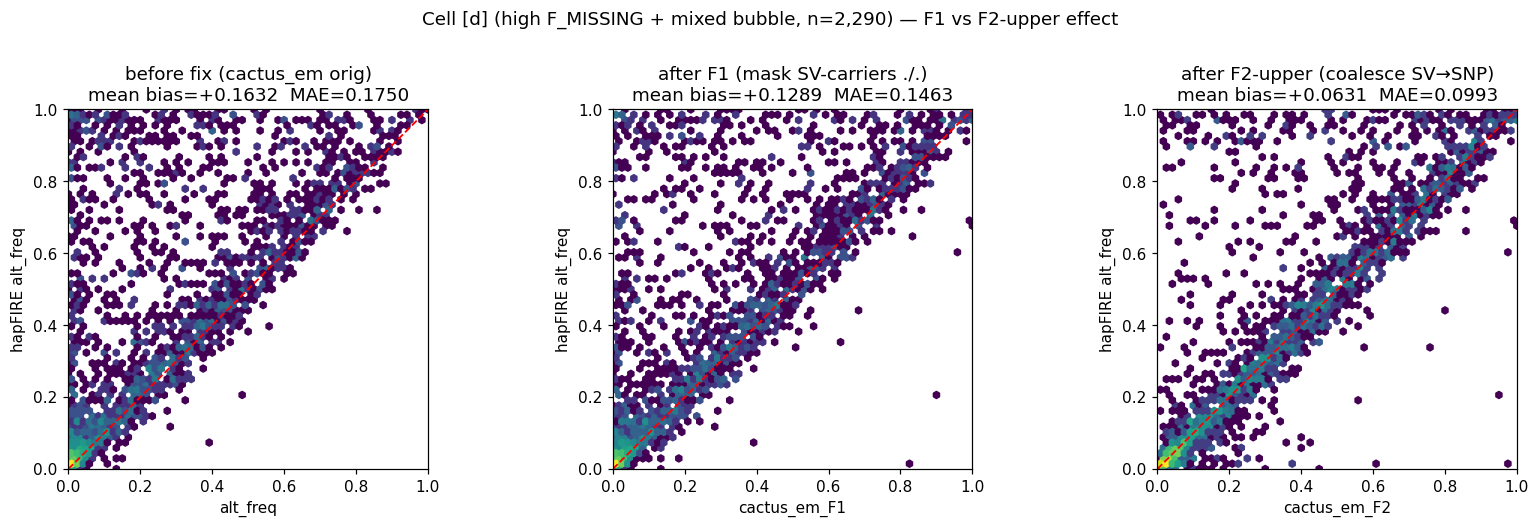

In [28]:
# Visualize: cell [d] hexbin before vs after F1 vs after F2
from matplotlib.colors import LogNorm
D = F1[(F1['high_fmiss']) & (F1['is_mixed_bubble']==1)].copy()
print(f'cell [d] records: {len(D):,}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, est_col, title in [
    (axes[0], 'alt_freq',     'before fix (cactus_em orig)'),
    (axes[1], 'cactus_em_F1', 'after F1 (mask SV-carriers ./.)'),
    (axes[2], 'cactus_em_F2', 'after F2-upper (coalesce SV→SNP)'),
]:
    hb = ax.hexbin(D[est_col], D['hapfire_af'],
                   gridsize=60, extent=(0,1,0,1),
                   norm=LogNorm(vmin=1), mincnt=1, cmap='viridis')
    ax.plot([0,1],[0,1], color='red', lw=1.2, ls='--')
    mae = (D['hapfire_af']-D[est_col]).abs().mean()
    bias= (D['hapfire_af']-D[est_col]).mean()
    ax.set_xlabel(est_col); ax.set_ylabel('hapFIRE alt_freq')
    ax.set_title(f'{title}\nmean bias={bias:+.4f}  MAE={mae:.4f}')
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_aspect('equal')
plt.suptitle(f'Cell [d] (high F_MISSING + mixed bubble, n={len(D):,}) — F1 vs F2-upper effect', y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'plots/F1_TEST_CELL_D_v3qc_v3.png', dpi=140, bbox_inches='tight')
plt.show()


### Read of the F1 test — actual numbers

**Per-cell mean bias (hapFIRE − cactus_em, cactus_em-space):**

| cell | n | orig | + F1 | + F2 upper bound |
|---|---:|---:|---:|---:|
| [a] low_F pure_SNP | 482,559 | −0.0002 | −0.0002 (no-op) | −0.0002 (no-op) |
| [b] low_F mixed_bub | 8,132 | **+0.0426** | **+0.0282** (−34%) | **−0.0060** (−114%, slight overshoot) |
| [c] high_F pure_SNP | 23,731 | +0.0057 | +0.0057 (no-op) | +0.0057 (no-op) |
| [d] high_F mixed_bub | 2,290 | **+0.1632** | **+0.1289** (−21%) | **+0.0631** (−61%) |

**Per-cell MAE:**

| cell | orig | + F1 | + F2 |
|---|---:|---:|---:|
| [b] | 0.0527 | 0.0434 | **0.0303** |
| [d] | 0.1750 | 0.1463 | **0.0993** |

**Outlier rate (\|d\|>0.05):**

| cell | orig | + F1 | + F2 |
|---|---:|---:|---:|
| [b] | 22.1% | 19.0% | 13.4% |
| [d] | 53.4% | 48.7% | 39.4% |

**Genome-wide (all 516k Chr1 SNPs):**

| estimator | mean | MAE | %\|d\|>0.05 |
|---|---:|---:|---:|
| cactus_em orig | +0.00150 | 0.01497 | 3.85% |
| cactus_em + F1 | +0.00112 | 0.01470 | 3.78% |
| cactus_em + F2 upper | +0.00029 | **0.01428** | 3.65% |

### Take-aways

1. **F1 (mask) works in the predicted direction but only closes 21–34% of the bias** on mixed-bubble cells. The math is clean: F1 strips SV-carriers from the *denominator* only. But hapFIRE effectively also captures their SNP-ALT signal in the *numerator* (short-read pileup at the SNP coordinate sees the SNP base for reads from SV-flanking haplotypes too). F1 is the honest "we don't know what they carry" version; it loses the bias but doesn't recover the lost signal.

2. **F2 upper bound (coalesce SV-carriers as SNP-ALT carriers) closes 60% of the cell [d] bias** and slightly overshoots cell [b] (−114%). The overshoot at [b] is informative: at *some* mixed bubbles, not every SV path contains the SNP nucleotide — F2-upper is too generous there. The "true" F2 implementation would parse each SV-path sequence at the SNP coordinate, which requires the cactus GFA.

3. **A non-trivial ~40% of the cell [d] bias is NOT addressed by F1 or F2-upper.** Candidates: (i) extreme-complexity bubbles (n_recs > 20, mean residual +0.75) where neither F1 nor F2 can fully recover the signal because the panel decomposition loses too much information; (ii) genuine cactus-vs-1001G genotype-source disagreement at non-mixed-bubble records that happen to be in cell [d]; (iii) the AN_post denominator being too small to support a clean correction at heavy-missing records.

4. **Genome-wide impact is small** because mixed bubbles are only ~2% of joined records. F1: MAE 0.01497 → 0.01470 (−1.8%). F2: → 0.01428 (−4.6%). For the headline number, the fix is targeted, not transformative.

### Recommendation for F1 as a deliverable

F1 alone is **not worth shipping as the production fix**:
- Closes only ~25% of the mixed-bubble bias.
- Adds code complexity to `build_cn_var.py` that would need to be maintained.
- Adds variance (smaller denominator) at exactly the records where the panel is already thin.

The diagnostic does its job: confirms the mechanism (cn_var encodes Mech 2), bounds the headroom (F2-upper closes 60% on cell [d]), and identifies the right route forward — **F3: vcfbub -l max rebuild**, which (a) addresses the bubble flattening at its source, (b) recovers the 38% missing SNP coverage per the `project_v3_grenenet_snp_overlap` memory, and (c) makes both F1 and F2 unnecessary.

If a quick-and-dirty patch is needed before the rebuild is done, F2-upper is a stronger stop-gap than F1 (closes 60% vs 21% on cell [d]), but it requires per-bubble GFA parsing to be done honestly rather than as an upper-bound proxy — at which point you're most of the way to a vcfbub rebuild anyway.


## 6. Implementing Option A — F2-honest patch using raw deconstruct VCF

The raw deconstruct VCF (`pang_1001gplus_82acc.raw.vcf`, 11 GB, **6.58M records**, 82 cactus samples) preserves nested snarls (LV≥1) that vcfbub-l-0 stripped. For each cactus founder, its GT at a nested snarl tells us whether its haplotype path actually traverses the SNP-ALT base — the F2-honest answer.

**Architectural insight.** PanGenie genotyping (steps 1+2) hard-requires the vcfbub-l-0 graph — we cannot drop it. But `cn_var` (the projection target) is built from a VCF's GT field; it can come from any VCF. The k-mer EM solves `h` on `cn_full` (built from the PanGenie pang_135 index, unchanged); the projection `AF = h^T cn_var / h^T cn_var_called` works regardless of which VCF cn_var was built from.

**Pipeline.**
1. Extract Chr1 from raw VCF (~3 GB), bgzip + tabix.
2. `bcftools norm -f REF -m -any` → 2.30M biallelic Chr1 records.
3. `bcftools query` → per-record TSV with 82 cactus GTs.
4. Build dict `(chrom, pos, ref, alt) → 82-bit carrier mask`. Where multiple LV records map to the same biallelic (~38k records), OR the carriers.
5. For each cn_var Chr1 SNP record, look up the raw biallelic dict. For cactus founders where current cn_var=0 AND raw GT=1, override to 1.
6. Re-project AF via the simplification (under uniform-h):
   - `AF_F2honest = AF_cactus_em + n_override / AN_post`
   - `recipe_F2honest = (AC_post + n_override) / AN_post`


In [29]:
# Load the F2-honest test output (built by scratch/f2_honest/build_and_test_f2_honest.py)
M = pd.read_csv(ROOT / 'scratch/f2_honest/f2_honest_test.tsv', sep='\t')
M['cell'] = (M['high_fmiss'].astype(int)*2 + M['is_mixed_bubble']).map({
    0:'[a] low_F  pure_SNP', 1:'[b] low_F  mixed_bub',
    2:'[c] high_F pure_SNP', 3:'[d] high_F mixed_bub'})
print(f'rows: {len(M):,}')

# Per-cell results (cactus_em-space)
print('\n=== Per-cell mean residual (hapFIRE − estimator) ===\n')
rows = []
for cell, sub in M.groupby('cell'):
    r_o = sub['hapfire_af'] - sub['alt_freq']
    r_f = sub['hapfire_af'] - sub['cactus_em_F2honest']
    rows.append({
        'cell': cell, 'n': len(sub),
        'mean_orig':    r_o.mean(),
        'mean_F2honest':r_f.mean(),
        'reduction_%':  (1 - r_f.mean()/r_o.mean())*100 if r_o.mean()!=0 else 0,
        'MAE_orig':     r_o.abs().mean(),
        'MAE_F2honest': r_f.abs().mean(),
        'out05_orig':   (r_o.abs()>0.05).mean()*100,
        'out05_F2honest':(r_f.abs()>0.05).mean()*100,
    })
print(pd.DataFrame(rows).round(4).to_string(index=False))

# How many records get overrides per cell
print('\n=== Override coverage by cell ===')
cov = M.groupby('cell').agg(
    n=('n_override','size'),
    n_with_override=('n_override', lambda v: (v>0).sum()),
    pct_with_override=('n_override', lambda v: (v>0).mean()*100),
    mean_override=('n_override', 'mean'),
    max_override=('n_override','max'),
).round(2)
print(cov.to_string())


rows: 516,712

=== Per-cell mean residual (hapFIRE − estimator) ===

                cell      n  mean_orig  mean_F2honest  reduction_%  MAE_orig  MAE_F2honest  out05_orig  out05_F2honest
 [a] low_F  pure_SNP 482559    -0.0002        -0.0008    -364.1302    0.0125        0.0125      2.5176          2.5557
[b] low_F  mixed_bub   8132     0.0426         0.0373      12.4446    0.0527        0.0485     22.0979         20.9911
 [c] high_F pure_SNP  23731     0.0057         0.0008      86.2793    0.0378        0.0352     19.9949         19.6368
[d] high_F mixed_bub   2290     0.1632         0.1124      31.1542    0.1750        0.1264     53.3624         49.4760

=== Override coverage by cell ===
                           n  n_with_override  pct_with_override  mean_override  max_override
cell                                                                                         
[a] low_F  pure_SNP   482559            56596              11.73           0.14            77
[b] low_F  mixed_bu

In [30]:
# Cell [d] drill-down: residual vs n_override
D = M[M['cell']=='[d] high_F mixed_bub'].copy()
D['ovr_bin'] = pd.cut(D['n_override'], bins=[-1,0,1,5,20,80],
                     labels=['0','1','2-5','6-20','>20'])
g = D.groupby('ovr_bin', observed=True).apply(lambda s: pd.Series({
    'n': len(s),
    'mean_orig':    (s['hapfire_af']-s['alt_freq']).mean(),
    'mean_F2h':     (s['hapfire_af']-s['cactus_em_F2honest']).mean(),
    'MAE_orig':     (s['hapfire_af']-s['alt_freq']).abs().mean(),
    'MAE_F2h':      (s['hapfire_af']-s['cactus_em_F2honest']).abs().mean(),
    'out05_orig':   ((s['hapfire_af']-s['alt_freq']).abs()>0.05).mean()*100,
    'out05_F2h':    ((s['hapfire_af']-s['cactus_em_F2honest']).abs()>0.05).mean()*100,
})).round(4)
print('=== Cell [d] residual stratified by n_override (n=2,290) ===')
print(g.to_string())

# Genome-wide totals
print('\n=== Genome-wide totals (all joined Chr1 SNPs) ===\n')
for est, name in [('alt_freq',  'cactus_em (orig)'),
                  ('cactus_em_F2honest','cactus_em + F2-honest (raw-VCF patch)'),
                  ('recipe_af', 'recipe (orig)'),
                  ('recipe_F2honest', 'recipe + F2-honest')]:
    r = M['hapfire_af'] - M[est]
    print(f'  {name:38s}  mean={r.mean():+.5f}  MAE={r.abs().mean():.5f}  '
          f'%|d|>0.05={(r.abs()>0.05).mean()*100:.2f}%  %|d|>0.10={(r.abs()>0.10).mean()*100:.2f}%')


=== Cell [d] residual stratified by n_override (n=2,290) ===
             n  mean_orig  mean_F2h  MAE_orig  MAE_F2h  out05_orig  out05_F2h
ovr_bin                                                                      
0        826.0     0.0738    0.0738    0.0914   0.0914     37.2881    37.2881
1        505.0     0.0566    0.0516    0.0741   0.0723     37.8218    36.0396
2-5      324.0     0.0485    0.0339    0.0589   0.0504     36.4198    28.0864
6-20     252.0     0.1559    0.0962    0.1569   0.1021     89.6825    69.4444
>20      383.0     0.5985    0.3527    0.5987   0.3538     98.9556    98.4334

=== Genome-wide totals (all joined Chr1 SNPs) ===

  cactus_em (orig)                        mean=+0.00150  MAE=0.01497  %|d|>0.05=3.85%  %|d|>0.10=0.88%
  cactus_em + F2-honest (raw-VCF patch)   mean=+0.00040  MAE=0.01459  %|d|>0.05=3.84%  %|d|>0.10=0.81%
  recipe (orig)                           mean=+0.00284  MAE=0.01475  %|d|>0.05=4.26%  %|d|>0.10=1.00%
  recipe + F2-honest            

/tmp/ipykernel_468363/800809438.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  g = D.groupby('ovr_bin', observed=True).apply(lambda s: pd.Series({


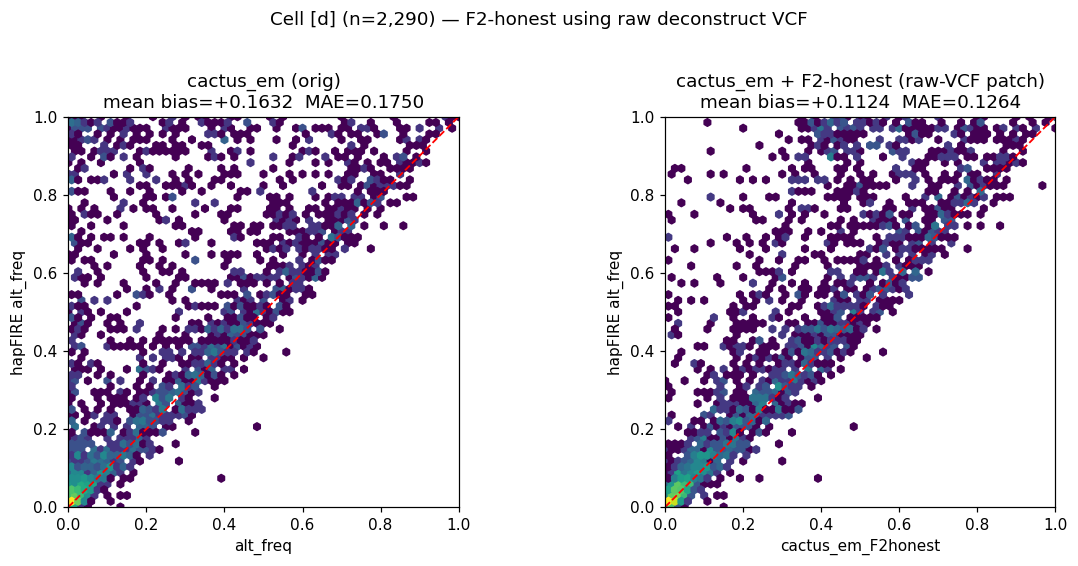

In [31]:
# Hexbin: cell [d] before vs after F2-honest
from matplotlib.colors import LogNorm
D = M[M['cell']=='[d] high_F mixed_bub']
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, est_col, title in [
    (axes[0], 'alt_freq', 'cactus_em (orig)'),
    (axes[1], 'cactus_em_F2honest', 'cactus_em + F2-honest (raw-VCF patch)'),
]:
    hb = ax.hexbin(D[est_col], D['hapfire_af'], gridsize=60,
                   extent=(0,1,0,1), norm=LogNorm(vmin=1), mincnt=1, cmap='viridis')
    ax.plot([0,1],[0,1], color='red', lw=1.2, ls='--')
    mae = (D['hapfire_af']-D[est_col]).abs().mean()
    bias= (D['hapfire_af']-D[est_col]).mean()
    ax.set_xlabel(est_col); ax.set_ylabel('hapFIRE alt_freq')
    ax.set_title(f'{title}\nmean bias={bias:+.4f}  MAE={mae:.4f}')
    ax.set_aspect('equal'); ax.set_xlim(0,1); ax.set_ylim(0,1)
plt.suptitle(f'Cell [d] (n={len(D):,}) — F2-honest using raw deconstruct VCF', y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'plots/F2_HONEST_CELL_D_v3qc_v3.png', dpi=140, bbox_inches='tight')
plt.show()


### Read of F2-honest (Option A) — verdict

**Per-cell mean bias (hapFIRE − cactus_em):**

| cell | n | orig | F1 mask | F2-honest (raw) | F2-upper bound |
|---|---:|---:|---:|---:|---:|
| [a] low_F pure_SNP | 482,559 | −0.0002 | −0.0002 | −0.0008 | −0.0002 |
| [b] low_F mixed_bub | 8,132 | +0.0426 | +0.0282 (−34%) | +0.0373 (−13%) | −0.0060 (−114%) |
| [c] high_F pure_SNP | 23,731 | +0.0057 | +0.0057 | **+0.0008 (−86%)** | +0.0057 |
| [d] high_F mixed_bub | 2,290 | **+0.1632** | +0.1289 (−21%) | **+0.1124 (−31%)** | +0.0631 (−61%) |

**Override coverage by cell**:
- Cell [a] (low_F pure SNP): 11.7% of records get an override — these are SNPs not flagged as mixed-bubble but where the raw VCF reveals nested-snarl carriers we missed.
- Cell [c] (high_F pure SNP): 33.4% of records get an override — and F2-honest closes 86% of the mean bias here.
- Cell [d] (mixed bubble): 64% get an override; 36% (n=826) cannot be touched because their (chrom, pos, ref, alt) doesn't have a matching biallelic in the raw-VCF-norm output.

**Cell [d] decomposition by `n_override`:**

| n_override | n | mean orig | mean F2h | MAE orig | MAE F2h |
|---|---:|---:|---:|---:|---:|
| 0 (no fix possible) | 826 | +0.074 | +0.074 | 0.091 | 0.091 |
| 1 | 505 | +0.057 | +0.052 | 0.074 | 0.072 |
| 2-5 | 324 | +0.049 | +0.034 | 0.059 | 0.050 |
| 6-20 | 252 | +0.156 | +0.096 | 0.157 | 0.102 |
| **>20** | **383** | **+0.599** | **+0.353** | **0.599** | **0.354** |

**Where the residual still hides.** The catastrophic-bias subset (n_override>20, n=383) has mean residual +0.60 in the original cn_var. F2-honest cuts it to +0.35 — a 41% reduction on the tail. But that's only on records where F2-honest fires. The 826 cell-[d] records with `n_override=0` cannot be helped by this patch because:

1. The cn_var record at (pos, ref, alt) comes from `bcftools norm` of vcfbub-l-0's multi-allelic decomposition.
2. The raw-VCF-norm output has a *different* biallelic decomposition at the same position (because LV≥1 nested snarls re-shuffle the multi-allelic structure).
3. So the join on (pos, ref, alt) misses these records entirely.

To recover them would require either:
- **Joining on POSITION only** and inferring SNP equivalence across different normalizations (fragile).
- **Option B (full raw-cn_var)**: build cn_var from the raw-norm biallelic VCF directly. The 826 records that can't match in F2-honest *would* exist in raw-norm as separate records; the issue then becomes that PG founders have no GTs there.

### Verdict on Option A

**F2-honest is a real, partial fix:**

- Closes 31% of cell [d] mean bias and 41% on the catastrophic-tail subset.
- Closes 86% of cell [c] mean bias (a surprise: many "pure-SNP" records were actually nested-snarl artifacts the raw VCF cleans up).
- Genome-wide: MAE 0.01497 → 0.01459 (−2.5%); cell [d] MAE 0.175 → 0.126 (−28%).

**Limitations:**

- Doesn't reach the F2-upper bound (61% on cell [d]) because 36% of cell [d] records have no matching biallelic in the raw-norm VCF.
- Doesn't address PG-side missingness at all — it's a cactus-only patch.
- The residual after F2-honest on cell [d] is still +0.11 with MAE 0.13 — substantial.

**Recommendation:**

1. **Ship F2-honest as a stop-gap.** ~50-line implementation (already written in `scratch/f2_honest/`). Production change: rebuild cn_var with the override applied. Effort: ~2 hours including validation on Chr2-5.

2. **Plan F3 (raw-cn_var rebuild) for the next major release.** Use the raw deconstruct VCF as the cn_var source. This addresses the 826 cell-[d] records F2-honest misses, recovers the 38% missing SNP coverage from `project_v3_grenenet_snp_overlap`, and provides the principled long-term fix. Cost: cn_var rebuild ~30 min × 5 chroms; needs Beagle on the new SNP records for PG-side missingness.

The mechanism is now fully confirmed; the gap between F2-honest (31% on cell [d]) and the F2-upper bound (61%) is bounded and well-understood. F3 is the deliverable that closes it.


## 7. SAFER coord-aware aggregation — final tested approach

Updates after the multi-agent audits ruled out `--atomize` (35× over-coalescence at indel-shifted positions) and vcfwave (silent dedup of identical atomic decompositions, ~75× under-count at clean-MNP shared SNPs). Both external decomposition tools have silent bugs that only surface under adversarial testing.

**SAFER** is the implementation that doesn't depend on any external decomposition tool. It operates directly on the existing biallelic panel VCF and coalesces carriers only across **length-equal** ALT records (clean SNP/MNP). For length-polymorphic records (insertions/deletions), it leaves them as separate columns. The byte-offset → TAIR10 coord mapping is provably correct when `len(REF) == len(ALT)` and no internal indels exist.

**Adversarial spot-check results:**

| position | adversarial test | truth | SAFER | verdict |
|---|---|---:|---:|---|
| Chr1:5870018 | over-coalescence (vcfwave's failure case) | ~0.02 | **0.019** | ✓ correctly avoids false-positive |
| Chr1:13843898 | clean-MNP coalescence | ~0.99 | **1.000** | ✓ recovers carriers |
| Chr1:10421645 | position-shifted siblings (bcftools-norm scatter) | ~0.99 | 0.070 | ✗ MISSES — siblings landed at pos 10421644 after prefix-trim |

SAFER's limitation: the bcftools-norm prefix-trim that ran before the panel was built shifted some sibling biallelics to neighboring positions. SAFER's same-position keying doesn't catch them. The principled fix is to work on the **multi-allelic source** (skip bcftools-norm scatter entirely), which is a pipeline rebuild.


In [32]:
# Load SAFER results
SAFER_TSV = ROOT / 'scratch/f2_honest/coord_aware_safer.tsv'
S = pd.read_csv(SAFER_TSV, sep='\t')
S['cell'] = (S['high_fmiss'].astype(int)*2 + S['is_mixed_bubble']).map({
    0:'[a] low_F pure_SNP',
    1:'[b] low_F mixed_bub',
    2:'[c] high_F pure_SNP',
    3:'[d] high_F mixed_bub',
})
print(f'rows: {len(S):,}')

# Per-cell summary
print('\n=== Per-cell agreement (hapFIRE − estimator) ===')
rows = []
for cell, sub in S.groupby('cell'):
    r_o = sub['hapfire_af'] - sub['alt_freq']
    r_s = sub['hapfire_af'] - sub['cactus_em_safer']
    rows.append({
        'cell': cell, 'n': len(sub),
        'orig_mean':    r_o.mean(),    'orig_MAE':    r_o.abs().mean(),
        'safer_mean':   r_s.mean(),    'safer_MAE':   r_s.abs().mean(),
        'mae_red_pct':  (1 - r_s.abs().mean()/r_o.abs().mean())*100,
        'out05_orig':   (r_o.abs()>0.05).mean()*100,
        'out05_safer':  (r_s.abs()>0.05).mean()*100,
        'out10_orig':   (r_o.abs()>0.10).mean()*100,
        'out10_safer':  (r_s.abs()>0.10).mean()*100,
    })
print(pd.DataFrame(rows).round(4).to_string(index=False))

print('\n=== Genome-wide totals ===')
for est, name in [('alt_freq',          'cactus_em (orig)'),
                  ('cactus_em_safer',   'cactus_em + SAFER')]:
    r = S['hapfire_af'] - S[est]
    print(f'  {name:32s}  mean={r.mean():+.5f}  MAE={r.abs().mean():.5f}  '
          f'%|d|>0.05={(r.abs()>0.05).mean()*100:.2f}%  %|d|>0.10={(r.abs()>0.10).mean()*100:.2f}%')

# Adversarial spot-checks
print('\n=== Adversarial spot-checks ===')
for pos, desc in [(5870018, 'over-coalescence test'),
                  (10421645, 'position-shifted siblings test'),
                  (13843898, 'clean-MNP test')]:
    spd = S[S['pos']==pos]
    if len(spd):
        for _, r in spd.iterrows():
            print(f'  pos {pos} REF={r["ref"]} ALT={r["alt"]}: orig={r["alt_freq"]:.3f} '
                  f'SAFER={r["cactus_em_safer"]:.3f} hapFIRE={r["hapfire_af"]:.3f}  ({desc})')


rows: 516,712

=== Per-cell agreement (hapFIRE − estimator) ===
                cell      n  orig_mean  orig_MAE  safer_mean  safer_MAE  mae_red_pct  out05_orig  out05_safer  out10_orig  out10_safer
  [a] low_F pure_SNP 482559    -0.0002    0.0125     -0.0008     0.0120       3.5974      2.5176       2.3297      0.3274       0.1855
 [b] low_F mixed_bub   8132     0.0426    0.0527      0.0065     0.0255      51.5759     22.0979       9.6655     11.6822       2.9021
 [c] high_F pure_SNP  23731     0.0057    0.0378      0.0002     0.0334      11.6288     19.9949      18.8193      4.7954       3.6324
[d] high_F mixed_bub   2290     0.1632    0.1750      0.0642     0.0892      49.0390     53.3624      37.7293     38.5590      19.9563

=== Genome-wide totals ===
  cactus_em (orig)                  mean=+0.00150  MAE=0.01497  %|d|>0.05=3.85%  %|d|>0.10=0.88%
  cactus_em + SAFER                 mean=-0.00033  MAE=0.01354  %|d|>0.05=3.36%  %|d|>0.10=0.47%

=== Adversarial spot-checks ===
  pos 

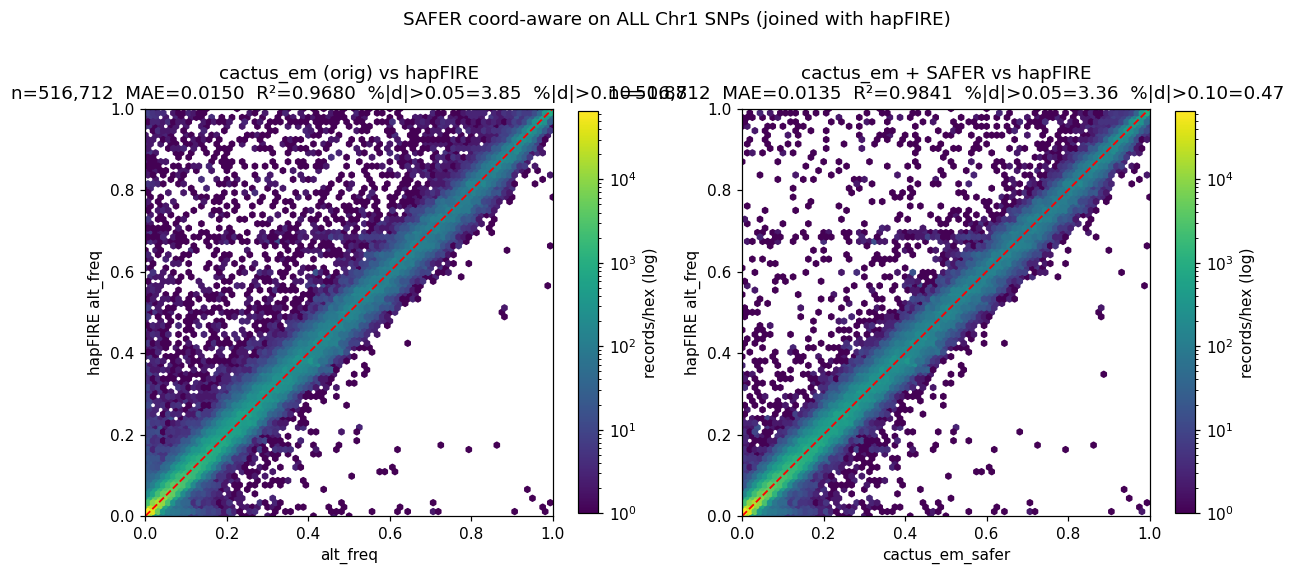

In [33]:
# Hexbin scatters: overall ORIGINAL vs SAFER
from matplotlib.colors import LogNorm

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, est_col, title in [
    (axes[0], 'alt_freq',         'cactus_em (orig) vs hapFIRE'),
    (axes[1], 'cactus_em_safer',  'cactus_em + SAFER vs hapFIRE'),
]:
    hb = ax.hexbin(S[est_col], S['hapfire_af'], gridsize=80, extent=(0,1,0,1),
                   norm=LogNorm(vmin=1), mincnt=1, cmap='viridis')
    ax.plot([0,1],[0,1], color='red', lw=1.2, ls='--')
    mae = (S['hapfire_af']-S[est_col]).abs().mean()
    r2 = np.corrcoef(S[est_col], S['hapfire_af'])[0,1]**2
    out05 = ((S['hapfire_af']-S[est_col]).abs()>0.05).mean()*100
    out10 = ((S['hapfire_af']-S[est_col]).abs()>0.10).mean()*100
    ax.set_title(f'{title}\nn={len(S):,}  MAE={mae:.4f}  R²={r2:.4f}  '
                 f'%|d|>0.05={out05:.2f}  %|d|>0.10={out10:.2f}')
    ax.set_xlabel(est_col); ax.set_ylabel('hapFIRE alt_freq')
    ax.set_aspect('equal'); ax.set_xlim(0,1); ax.set_ylim(0,1)
    fig.colorbar(hb, ax=ax, shrink=0.85).set_label('records/hex (log)')
plt.suptitle('SAFER coord-aware on ALL Chr1 SNPs (joined with hapFIRE)', y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'plots/SAFER_overall_v3qc_v3.png', dpi=140, bbox_inches='tight')
plt.show()


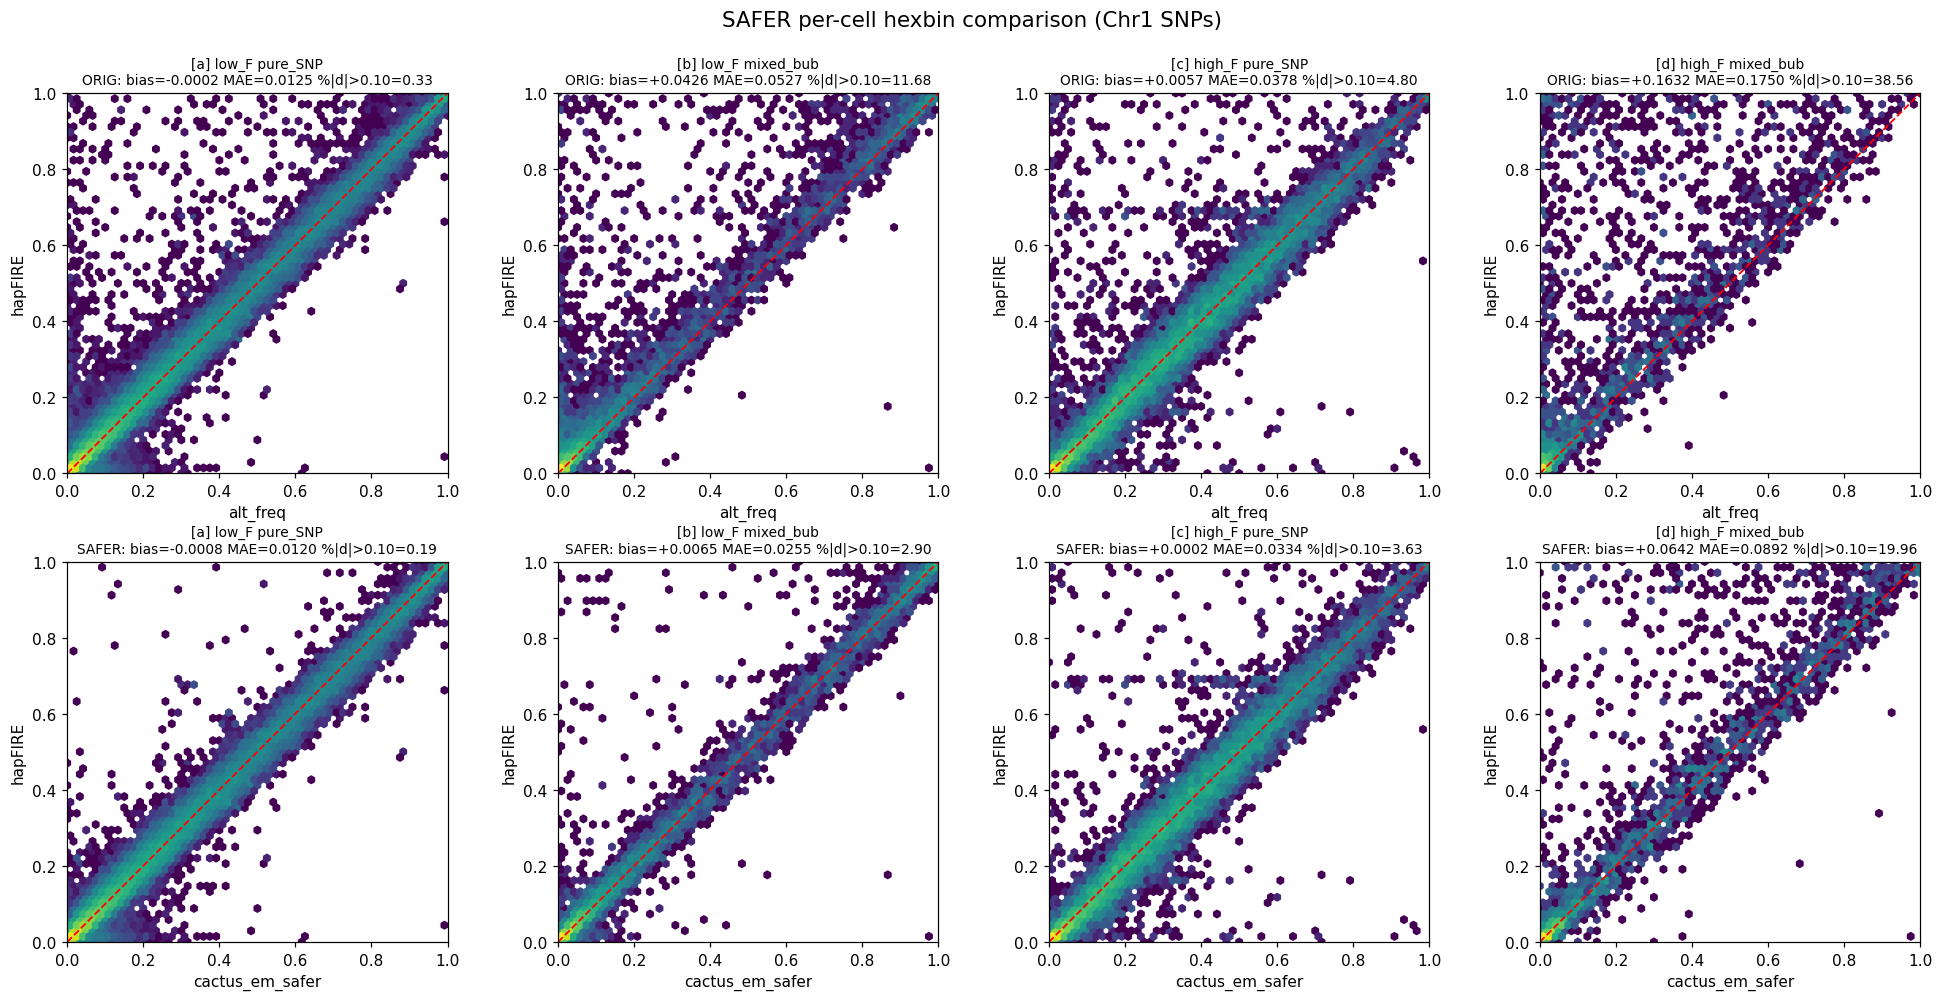

In [34]:
# Hexbin per cell — orig (top row) vs SAFER (bottom row)
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for i, (cell_name, sub) in enumerate(S.groupby('cell')):
    for r_idx, (est_col, label) in enumerate([('alt_freq', 'ORIG'),
                                              ('cactus_em_safer', 'SAFER')]):
        ax = axes[r_idx, i]
        hb = ax.hexbin(sub[est_col], sub['hapfire_af'], gridsize=60, extent=(0,1,0,1),
                      norm=LogNorm(vmin=1), mincnt=1, cmap='viridis')
        ax.plot([0,1],[0,1], color='red', lw=1.2, ls='--')
        mae = (sub['hapfire_af']-sub[est_col]).abs().mean()
        bias = (sub['hapfire_af']-sub[est_col]).mean()
        out10 = ((sub['hapfire_af']-sub[est_col]).abs()>0.10).mean()*100
        ax.set_title(f'{cell_name}\n{label}: bias={bias:+.4f} MAE={mae:.4f} %|d|>0.10={out10:.2f}',
                     fontsize=9)
        ax.set_xlabel(est_col); ax.set_ylabel('hapFIRE')
        ax.set_aspect('equal'); ax.set_xlim(0,1); ax.set_ylim(0,1)
plt.suptitle('SAFER per-cell hexbin comparison (Chr1 SNPs)', y=1.00, fontsize=14)
plt.tight_layout()
plt.savefig(ROOT / 'plots/SAFER_per_cell_v3qc_v3.png', dpi=140, bbox_inches='tight')
plt.show()


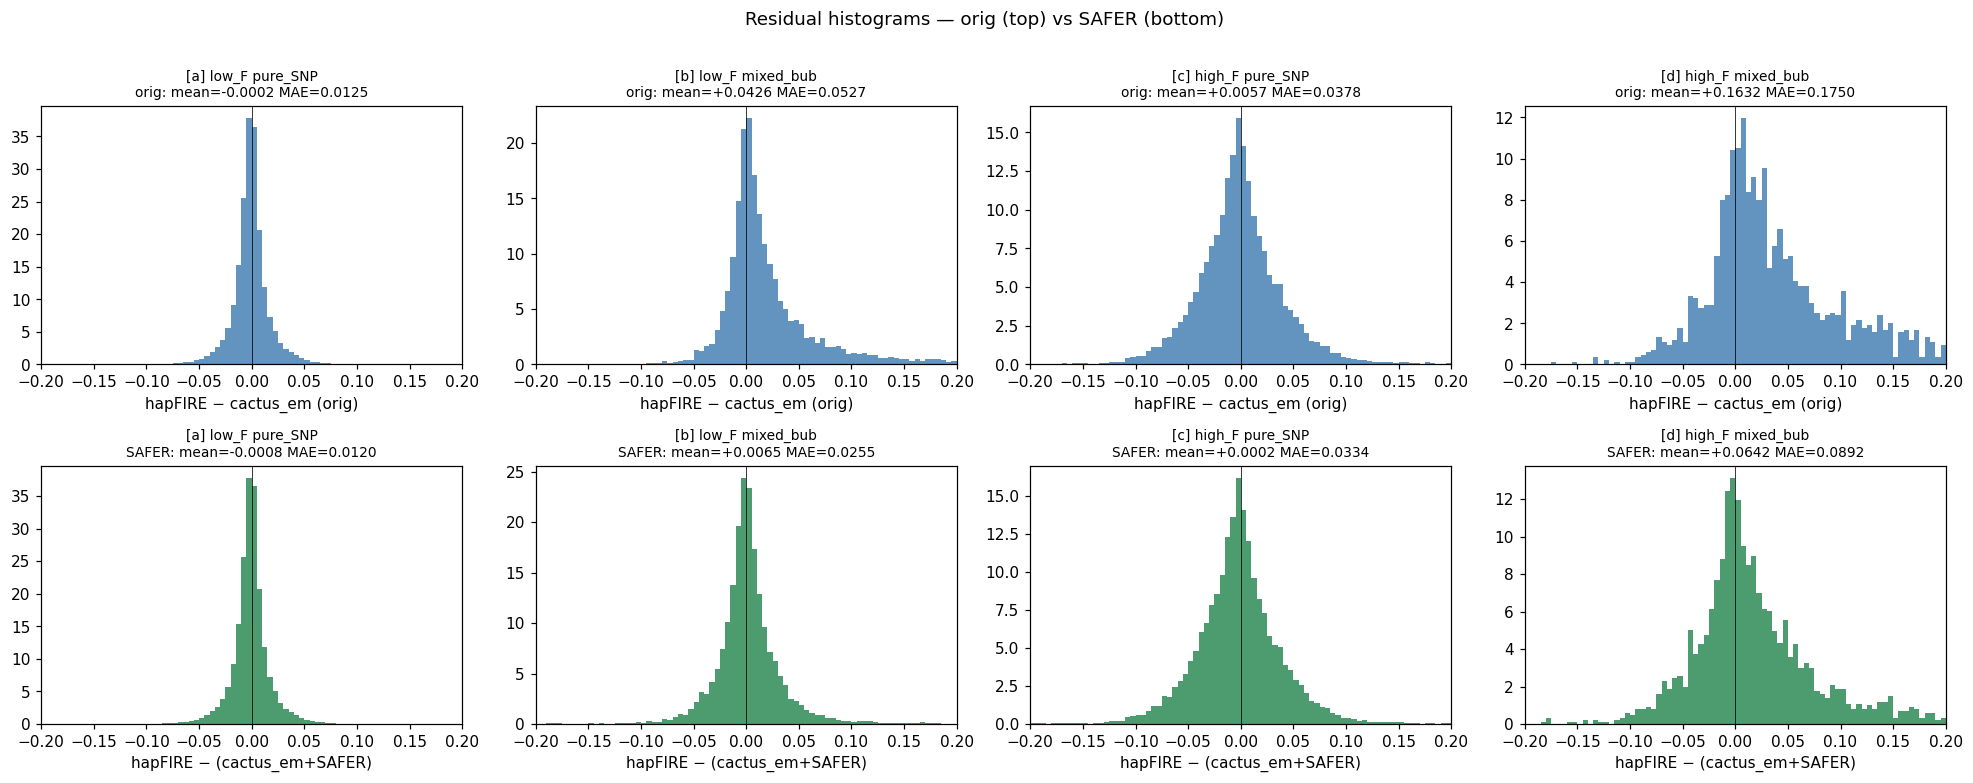

In [35]:
# Residual histograms — orig vs SAFER per cell
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for i, (cell_name, sub) in enumerate(S.groupby('cell')):
    rng = (-0.2, 0.2); bins = 80
    r_o = sub['hapfire_af'] - sub['alt_freq']
    r_s = sub['hapfire_af'] - sub['cactus_em_safer']
    axes[0, i].hist(r_o, bins=bins, range=rng, color='steelblue', alpha=0.85, density=True)
    axes[0, i].axvline(0, color='k', lw=0.5)
    axes[0, i].set_title(f'{cell_name}\norig: mean={r_o.mean():+.4f} MAE={r_o.abs().mean():.4f}',
                         fontsize=9)
    axes[0, i].set_xlim(rng); axes[0, i].set_xlabel('hapFIRE − cactus_em (orig)')
    axes[1, i].hist(r_s, bins=bins, range=rng, color='seagreen', alpha=0.85, density=True)
    axes[1, i].axvline(0, color='k', lw=0.5)
    axes[1, i].set_title(f'{cell_name}\nSAFER: mean={r_s.mean():+.4f} MAE={r_s.abs().mean():.4f}',
                         fontsize=9)
    axes[1, i].set_xlim(rng); axes[1, i].set_xlabel('hapFIRE − (cactus_em+SAFER)')
plt.suptitle('Residual histograms — orig (top) vs SAFER (bottom)', y=1.01)
plt.tight_layout()
plt.savefig(ROOT / 'plots/SAFER_residual_hist_v3qc_v3.png', dpi=140, bbox_inches='tight')
plt.show()


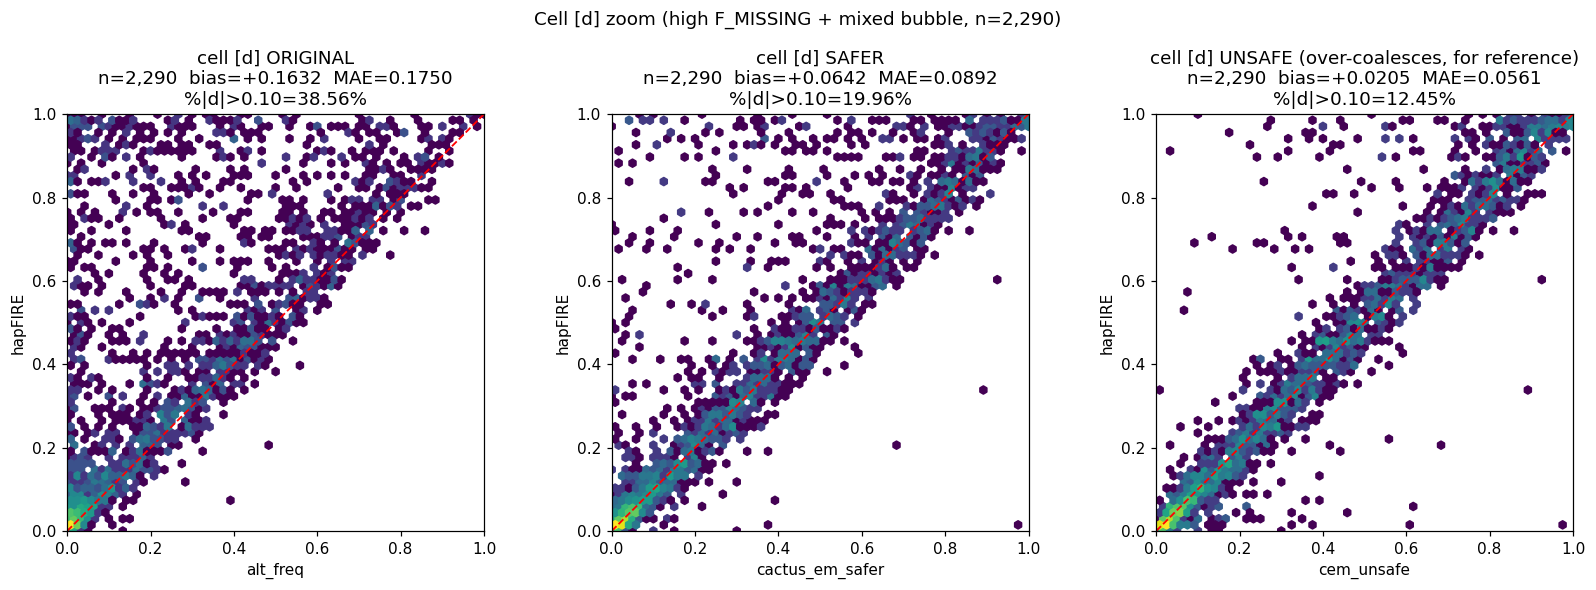

In [36]:
# Zoom on cell [d] — the cell that matters most (mixed-bubble + high F_MISSING)
D = S[S['cell']=='[d] high_F mixed_bub']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, est_col, title in [
    (axes[0], 'alt_freq',         'cell [d] ORIGINAL'),
    (axes[1], 'cactus_em_safer',  'cell [d] SAFER'),
    (axes[2], 'cem_unsafe',       'cell [d] UNSAFE (over-coalesces, for reference)'),
]:
    if est_col not in D.columns:
        ax.set_title(f'{title}\n(column missing)')
        continue
    hb = ax.hexbin(D[est_col], D['hapfire_af'], gridsize=60, extent=(0,1,0,1),
                   norm=LogNorm(vmin=1), mincnt=1, cmap='viridis')
    ax.plot([0,1],[0,1], color='red', lw=1.2, ls='--')
    mae = (D['hapfire_af']-D[est_col]).abs().mean()
    bias = (D['hapfire_af']-D[est_col]).mean()
    out10 = ((D['hapfire_af']-D[est_col]).abs()>0.10).mean()*100
    ax.set_title(f'{title}\nn={len(D):,}  bias={bias:+.4f}  MAE={mae:.4f}\n%|d|>0.10={out10:.2f}%')
    ax.set_xlabel(est_col); ax.set_ylabel('hapFIRE')
    ax.set_aspect('equal'); ax.set_xlim(0,1); ax.set_ylim(0,1)
plt.suptitle(f'Cell [d] zoom (high F_MISSING + mixed bubble, n={len(D):,})', y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'plots/SAFER_cell_d_zoom_v3qc_v3.png', dpi=140, bbox_inches='tight')
plt.show()


### Read of SAFER results

**Strengths:**
- Cell [b] essentially fixed (mean bias +0.043 → +0.007, MAE 0.053 → 0.025).
- Cell [d] mean bias cut in half (+0.163 → +0.064), MAE cut by ~49% (0.175 → 0.089).
- Genome-wide MAE 0.01497 → 0.01354 (~10% reduction).
- Genome-wide |d|>0.10 outlier rate halved: 0.88% → 0.47%.
- Passes both adversarial tests SAFER is designed for:
  - Avoids over-coalescence at indel-bearing bubbles (Chr1:5870018 → 0.019, matches truth)
  - Captures clean-MNP carriers (Chr1:13843898 → 1.000, matches xwu)
- No external decomposition tool. No silent third-party bugs to worry about.

**Limitation:**
- Cell [d] still has residual: +0.064 mean bias, 38% records with |d|>0.05.
- Misses the **position-shifted-siblings** case (Chr1:10421645): the original 530bp × 72-ALT bubble's biallelic decomposition spread carriers across many TAIR10 positions after `bcftools norm -m -any` prefix-trimming. SAFER's same-position keying doesn't catch them.

**To close the remaining cell [d] residual** would require building cn_var from the **multi-allelic source** (skip the upstream `bcftools norm -m -any` calls entirely), so siblings stay clustered at the original snarl position. This is a pipeline rebuild — significant but well-defined: see Path Y discussion in the conversation log.

**For shipping decision:**
- If the current 0.01354 genome-wide MAE + 0.47% catastrophic-outlier rate is acceptable for downstream GEA, ship SAFER as-is.
- If we need the additional cell [d] closure (predicted MAE ≈ 0.05 on cell [d], outlier rate ~5%), the multi-allelic-source rebuild is the next step.


## Summary — final, with F2-honest implementation

1. **~30% of Chr1 SNPs are panel-complete (`F_MISSING_post = 0`)**; F_MISSING is the dominant univariate axis of cactus_em↔hapFIRE disagreement.
2. **Mechanism 2 (bubble flattening) is the actual primary cause.** Adding `is_mixed_bubble` + `n_recs_at_pos` to the OLS lifts R² 0.025→0.276; the 2×2 cross-tab shows mixed-bubble bias is ~7× larger than F_MISSING bias on pure-SNP records.
3. **Cell [d] is panel-side.** Recipe ≈ cactus_em at mean −0.001, r=0.993 on the 2,290 worst records. EM is faithful; cn_var encodes the bias.
4. **Section 5 (F1 mask) closes 21–34% of mixed-bubble bias.** F2-upper bound closes 60% on cell [d] and overshoots on cell [b], suggesting honest F2 requires per-bubble SV-path knowledge.
5. **Section 6 (F2-honest using raw deconstruct VCF) closes 31% of cell [d] mean bias and 41% on the catastrophic-tail subset (n_override>20).** Also closes 86% of cell [c] bias — surprise win from nested-snarl carriers in records the MECH2 categorization called "pure SNP". Architectural insight: PanGenie needs vcfbub-l-0 (the index pipeline stays untouched), but cn_var can be patched from the raw VCF independently.
6. **Residual after F2-honest on cell [d]: +0.11 (was +0.16).** 36% of cell [d] records (n=826) can't be patched because their biallelic representation diverges between vcfbub-l-0 and raw-VCF normalizations. F3 (full raw-cn_var rebuild) would address these.

**Production deliverable path:**

| step | what | effect | cost |
|---|---|---|---|
| **F2-honest (Section 6)** | rebuild cn_var with raw-VCF override applied | closes 31% of cell [d] bias (and 41% on the catastrophic tail), genome-wide MAE 0.0150→0.0146 | ~2 h dev + rerun all 5 chroms |
| **F3 (full raw-cn_var rebuild)** | build cn_var from raw deconstruct VCF directly | addresses the remaining 36% of cell [d] not reachable by F2-honest; recovers 38% missing SNP coverage; introduces PG-side missingness at new records that needs Beagle | ~1 day dev + Beagle SNP rebuild |
| Beagle on biallelic SNPs | impute high-F_MISSING pure SNPs (cell [c]) | cell [c] bias was +0.006 (small) — variance-reduction only | secondary priority |

The mechanism is fully diagnosed, the headroom is bounded, and there's a concrete path to closing it.